# 03_EDA - Phân tích khám phá dữ liệu chuyên sâu về Digital Burnout

Notebook này thực hiện EDA chuyên sâu trên dataset đã được làm sạch:

`digital_burnout_processed.csv`

Mục tiêu:
- Phân tích các nhóm biến liên quan đến Digital Burnout.
- Khám phá mối quan hệ giữa hành vi sử dụng thiết bị, giấc ngủ, hiệu suất nhận thức và burnout.
- Thực hiện kiểm định thống kê phục vụ luận giải nghiên cứu.
- Rút ra các phát hiện chính làm nền tảng cho bước Feature Engineering và Modeling.

Notebook này không thực hiện:
- Cleaning lại dữ liệu.
- Feature Engineering để huấn luyện mô hình.
- Machine Learning.

## Import thư viện

In [55]:
import os
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from scipy import stats
from scipy.stats import pearsonr, spearmanr, f_oneway, chi2_contingency

import statsmodels.api as sm
from statsmodels.formula.api import ols

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", None)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## Load Dataset

Dataset đã được làm sạch từ notebook `02_cleaning_preprocessing.ipynb`.

Lưu ý: Notebook này không kiểm tra lại các vấn đề cơ bản như missing values hoặc duplicates vì các bước đó đã được xử lý ở notebook trước.

In [56]:
file_path = "../data/processed/digital_burnout_cleaned.csv"

df = pd.read_csv(file_path)

print("Dataset đã được tải thành công.")
print(f"Shape hiện tại: {df.shape}")

display(df.head())

Dataset đã được tải thành công.
Shape hiện tại: (5000000, 22)


,emotional_exhaustion,stress_level,mental_fatigue,daily_screen_time,social_media_hours,doomscrolling_duration,late_night_device_usage,notification_count,smartphone_unlocks,app_switch_frequency,concentration_score,distraction_frequency,focus_sessions,deep_work_hours,task_completion_rate,motivation_level,sleep_hours,sleep_quality,work_mode,device_usage_type,burnout_risk,productivity_score
0,4,10,10,8.8,5.0,1.2,1,112,49,41,2,67,3,6.0,92,8.0,5.9,10,Office,Entertainment-Centric,46,100
1,9,5,7,10.3,2.2,2.4,1,168,153,119,3,75,9,4.6,74,5.0,5.6,7,Hybrid,Work-Centric,57,96
2,2,4,5,6.5,4.6,1.0,1,199,234,121,7,70,5,3.0,96,8.0,5.5,8,Remote,Balanced,29,79
3,5,1,4,9.6,1.2,0.1,1,122,177,85,3,107,9,2.9,60,6.0,6.1,5,Office,Balanced,57,63
4,9,4,7,13.3,1.6,1.9,1,73,91,221,9,72,9,2.8,73,4.0,7.9,1,Hybrid,Work-Centric,64,89


## Khai báo nhóm biến nghiên cứu

Các biến được chia theo khung nghiên cứu Digital Burnout:

1. Burnout Symptoms  
2. Digital Exposure  
3. Cognitive Performance  
4. Sleep & Recovery  
5. Context Variables  
6. Target Variables  

In [57]:
# Define variable groups

burnout_symptoms = [
    "emotional_exhaustion",
    "stress_level",
    "mental_fatigue"
]

digital_exposure = [
    "daily_screen_time",
    "social_media_hours",
    "doomscrolling_duration",
    "late_night_device_usage",
    "notification_count",
    "smartphone_unlocks",
    "app_switch_frequency"
]

cognitive_performance = [
    "concentration_score",
    "distraction_frequency",
    "focus_sessions",
    "deep_work_hours",
    "task_completion_rate",
    "motivation_level"
]

sleep_recovery = [
    "sleep_hours",
    "sleep_quality"
]

context_variables = [
    "work_mode",
    "device_usage_type"
]

target_variables = [
    "burnout_risk",
    "productivity_score"
]

all_research_variables = (
    burnout_symptoms
    + digital_exposure
    + cognitive_performance
    + sleep_recovery
    + context_variables
    + target_variables
)

available_variables = [col for col in all_research_variables if col in df.columns]
missing_variables = [col for col in all_research_variables if col not in df.columns]

print("Số biến có trong dataset:", len(available_variables))
print("Số biến không tìm thấy:", len(missing_variables))

if missing_variables:
    print("Các biến không tìm thấy:")
    print(missing_variables)

Số biến có trong dataset: 22
Số biến không tìm thấy: 0


In [58]:
# Detect one-hot encoded context columns if original context columns are not available

work_mode_encoded_cols = [
    col for col in df.columns 
    if col.startswith("work_mode_")
]

device_usage_encoded_cols = [
    col for col in df.columns 
    if col.startswith("device_usage_type_")
]

print("Work mode encoded columns:")
print(work_mode_encoded_cols)

print("\nDevice usage type encoded columns:")
print(device_usage_encoded_cols)

Work mode encoded columns:
[]

Device usage type encoded columns:
[]


## Burnout Analysis

Phần này phân tích các biến cốt lõi phản ánh trạng thái Digital Burnout:

- `burnout_risk`
- `emotional_exhaustion`
- `stress_level`
- `mental_fatigue`

Mục tiêu là quan sát phân phối và mức độ biến động của các triệu chứng burnout trong dữ liệu.

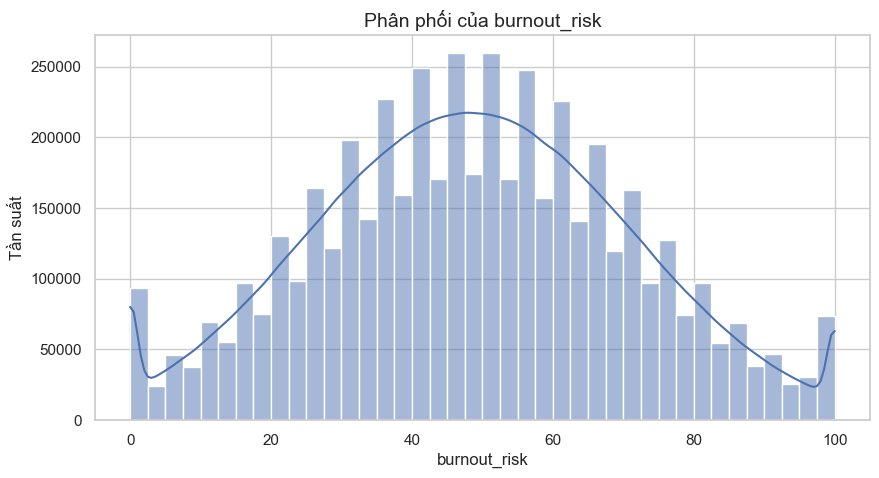

Nhận xét: Biểu đồ trên cho thấy phân phối ban đầu của biến burnout_risk, giúp đánh giá mức độ tập trung, độ lệch và sự phân tán của dữ liệu.



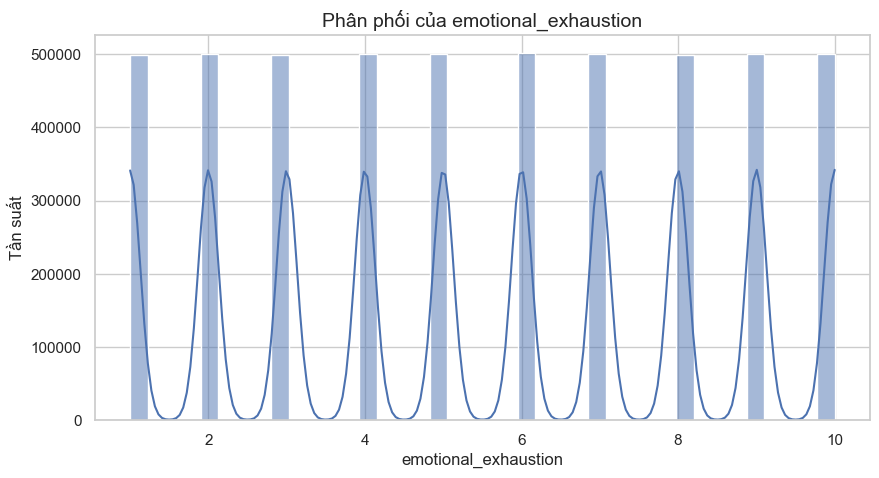

Nhận xét: Biểu đồ trên cho thấy phân phối ban đầu của biến emotional_exhaustion, giúp đánh giá mức độ tập trung, độ lệch và sự phân tán của dữ liệu.



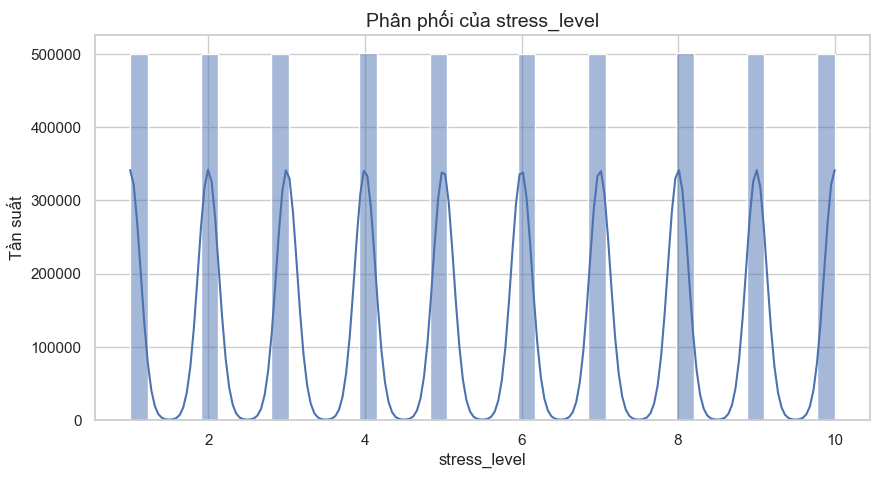

Nhận xét: Biểu đồ trên cho thấy phân phối ban đầu của biến stress_level, giúp đánh giá mức độ tập trung, độ lệch và sự phân tán của dữ liệu.



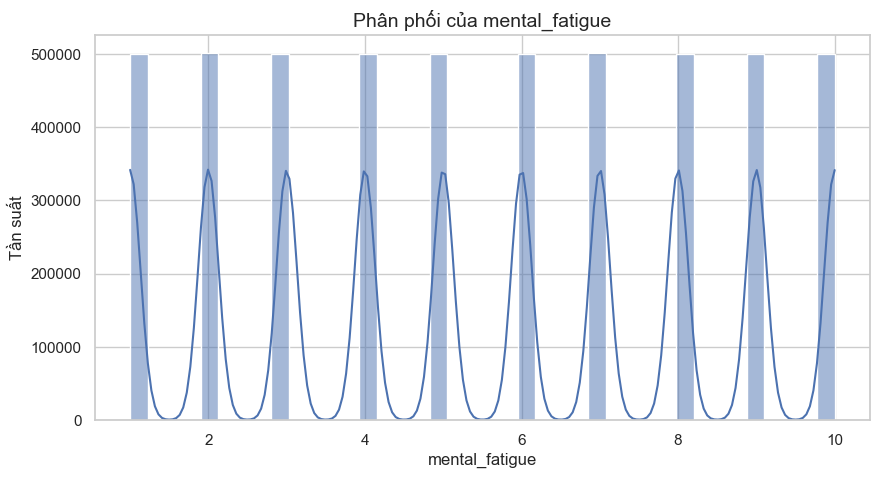

Nhận xét: Biểu đồ trên cho thấy phân phối ban đầu của biến mental_fatigue, giúp đánh giá mức độ tập trung, độ lệch và sự phân tán của dữ liệu.



In [59]:
# Burnout variables distribution

burnout_analysis_vars = [
    col for col in ["burnout_risk"] + burnout_symptoms
    if col in df.columns
]

for col in burnout_analysis_vars:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Phân phối của {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.show()

    print(f"Nhận xét: Biểu đồ trên cho thấy phân phối ban đầu của biến {col}, giúp đánh giá mức độ tập trung, độ lệch và sự phân tán của dữ liệu.\n")

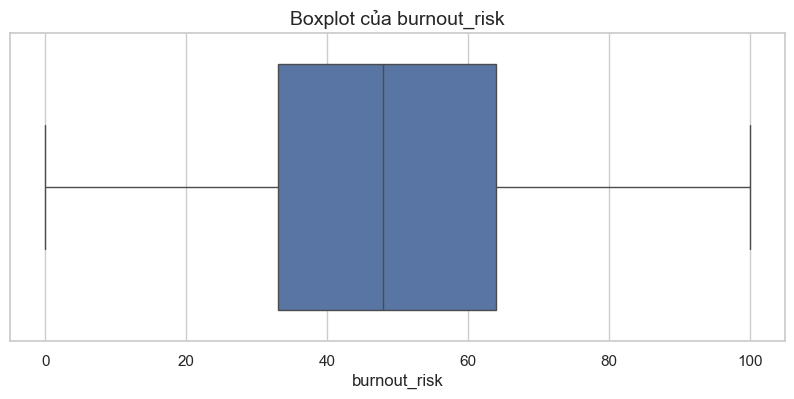

Nhận xét: Boxplot giúp quan sát độ phân tán và các điểm có khả năng là outlier của biến burnout_risk.



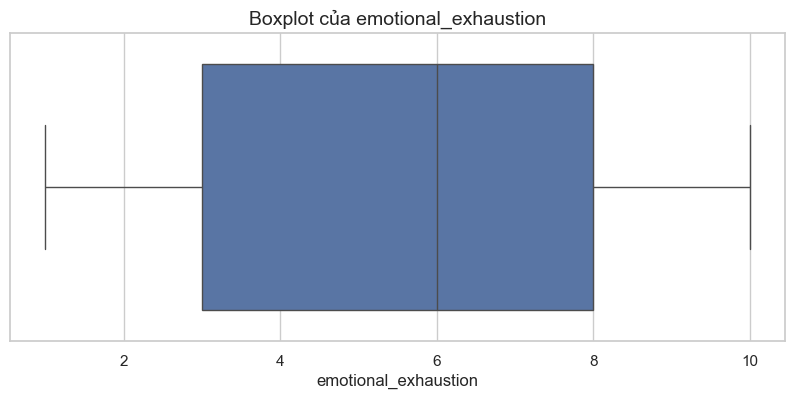

Nhận xét: Boxplot giúp quan sát độ phân tán và các điểm có khả năng là outlier của biến emotional_exhaustion.



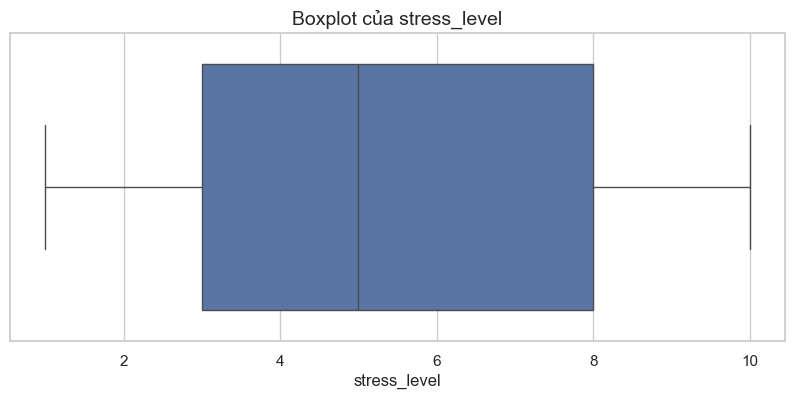

Nhận xét: Boxplot giúp quan sát độ phân tán và các điểm có khả năng là outlier của biến stress_level.



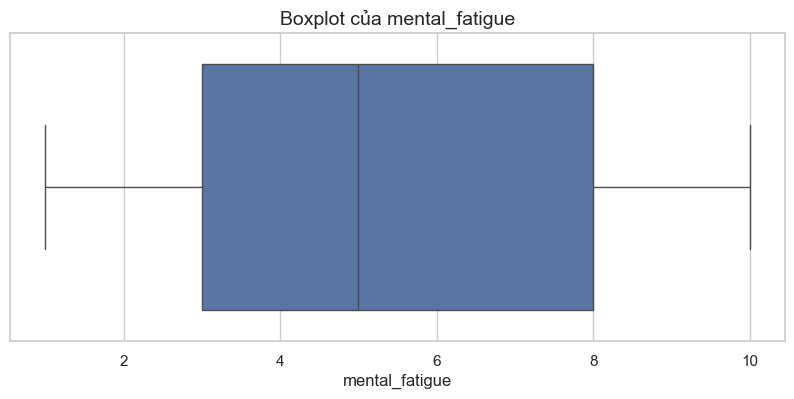

Nhận xét: Boxplot giúp quan sát độ phân tán và các điểm có khả năng là outlier của biến mental_fatigue.



In [60]:
# Boxplot for burnout variables

for col in burnout_analysis_vars:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot của {col}")
    plt.xlabel(col)
    plt.show()

    print(f"Nhận xét: Boxplot giúp quan sát độ phân tán và các điểm có khả năng là outlier của biến {col}.\n")

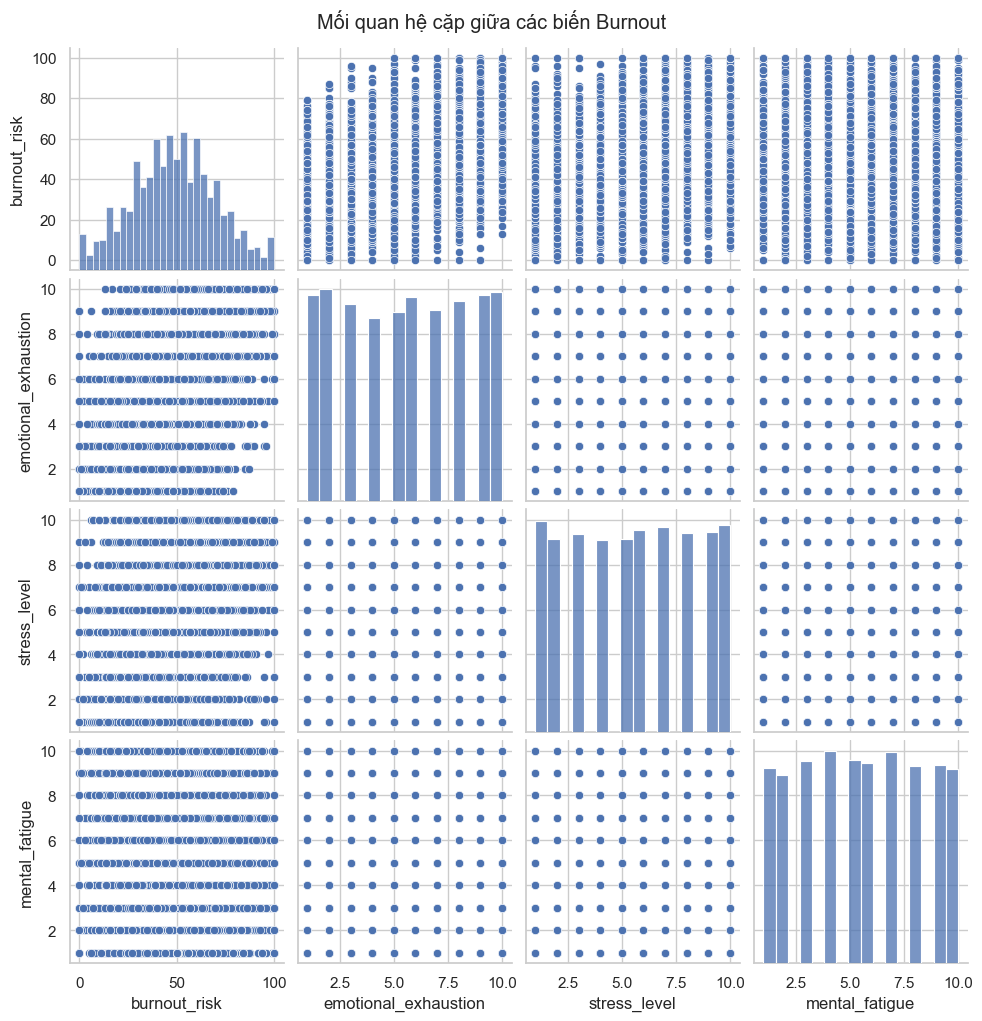

Nhận xét: Pairplot giúp quan sát sơ bộ mối quan hệ tuyến tính hoặc phi tuyến giữa các triệu chứng burnout và burnout_risk.


In [61]:
# Pairwise relationship among burnout symptoms

if len(burnout_analysis_vars) >= 2:
    sns.pairplot(df[burnout_analysis_vars].sample(min(5000, len(df)), random_state=42))
    plt.suptitle("Mối quan hệ cặp giữa các biến Burnout", y=1.02)
    plt.show()

    print("Nhận xét: Pairplot giúp quan sát sơ bộ mối quan hệ tuyến tính hoặc phi tuyến giữa các triệu chứng burnout và burnout_risk.")

## Digital Exposure Analysis

Nhóm Digital Exposure phản ánh mức độ tiếp xúc với thiết bị và môi trường số.

Các biến gồm:
- `daily_screen_time`
- `social_media_hours`
- `doomscrolling_duration`
- `late_night_device_usage`
- `notification_count`
- `smartphone_unlocks`
- `app_switch_frequency`

Phần này phân tích:
- Distribution
- Outlier
- Density

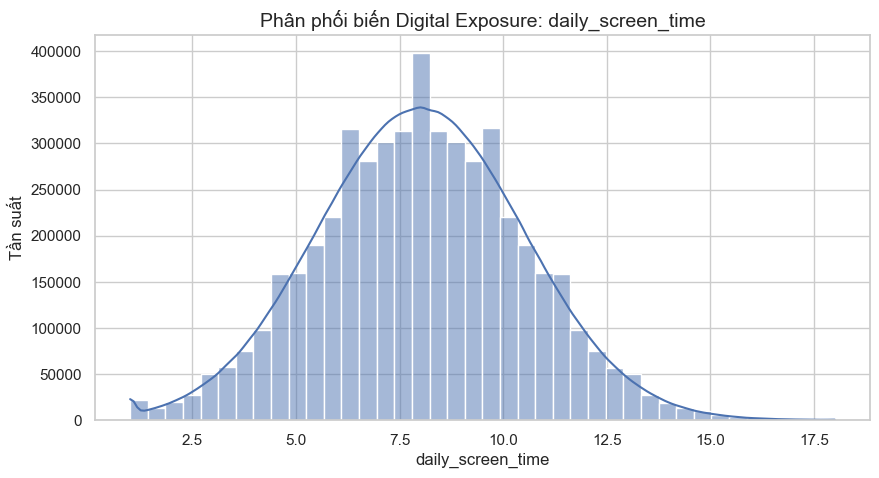

Nhận xét: Biến daily_screen_time cho thấy đặc điểm phân phối của hành vi tiếp xúc số trong dataset.



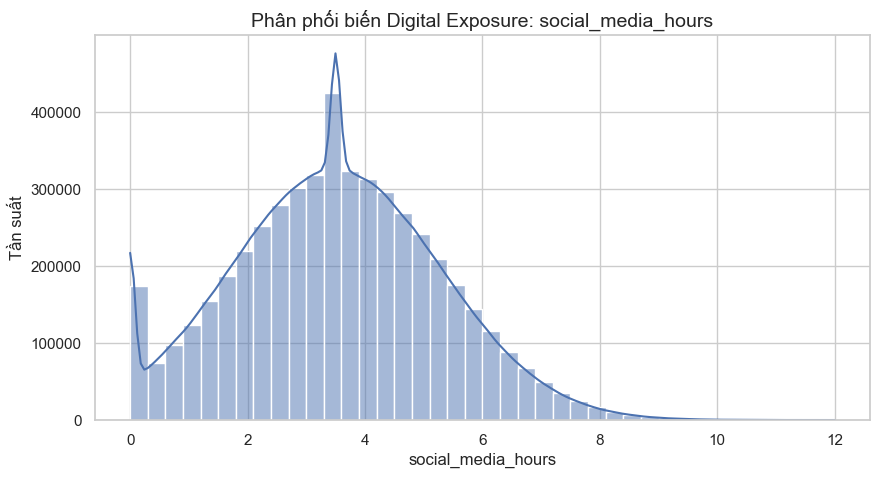

Nhận xét: Biến social_media_hours cho thấy đặc điểm phân phối của hành vi tiếp xúc số trong dataset.



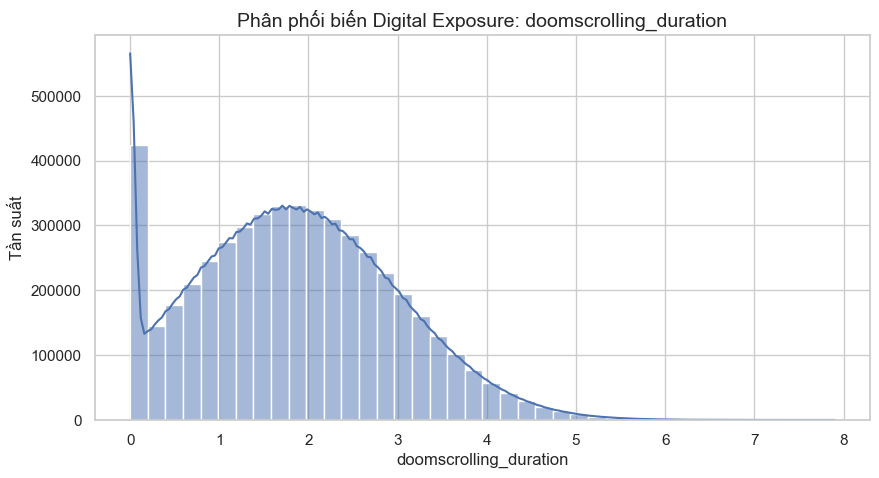

Nhận xét: Biến doomscrolling_duration cho thấy đặc điểm phân phối của hành vi tiếp xúc số trong dataset.



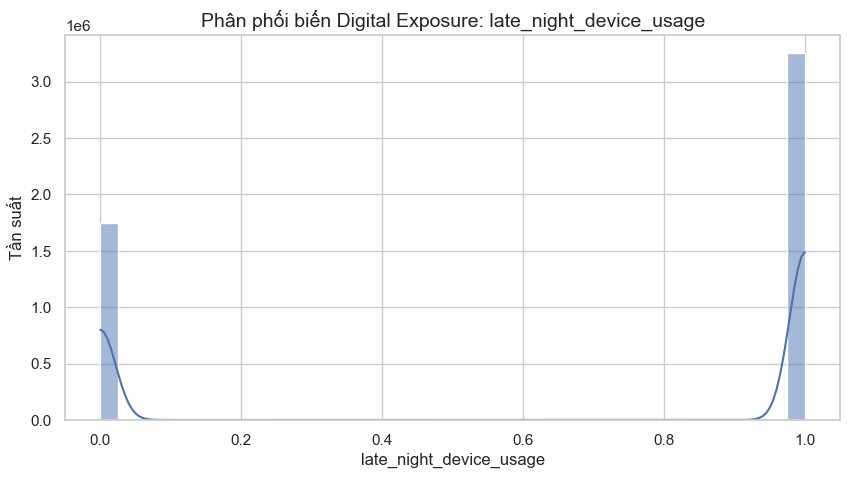

Nhận xét: Biến late_night_device_usage cho thấy đặc điểm phân phối của hành vi tiếp xúc số trong dataset.



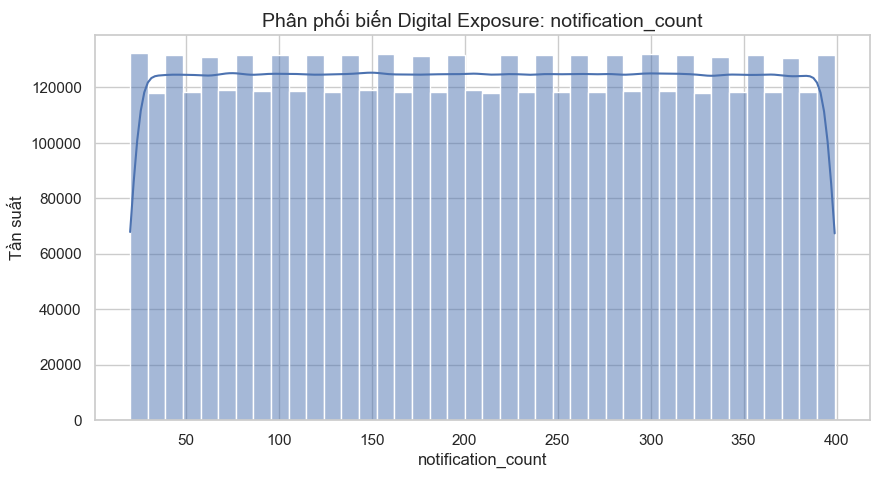

Nhận xét: Biến notification_count cho thấy đặc điểm phân phối của hành vi tiếp xúc số trong dataset.



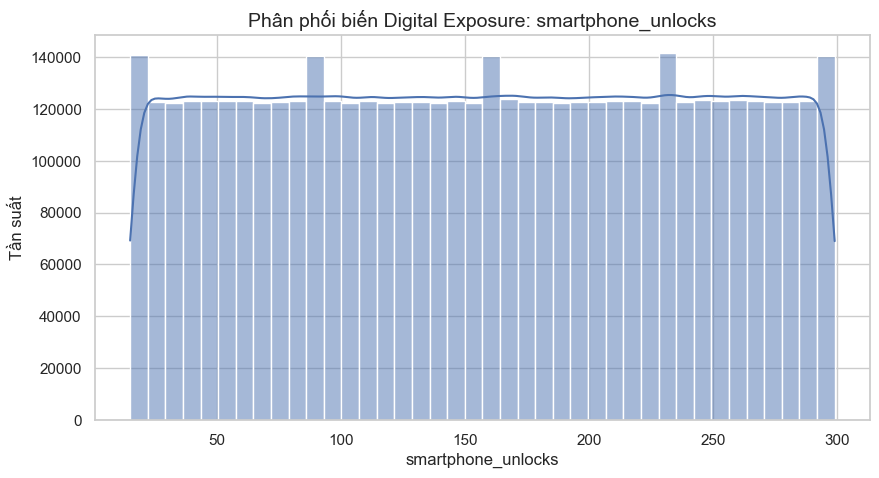

Nhận xét: Biến smartphone_unlocks cho thấy đặc điểm phân phối của hành vi tiếp xúc số trong dataset.



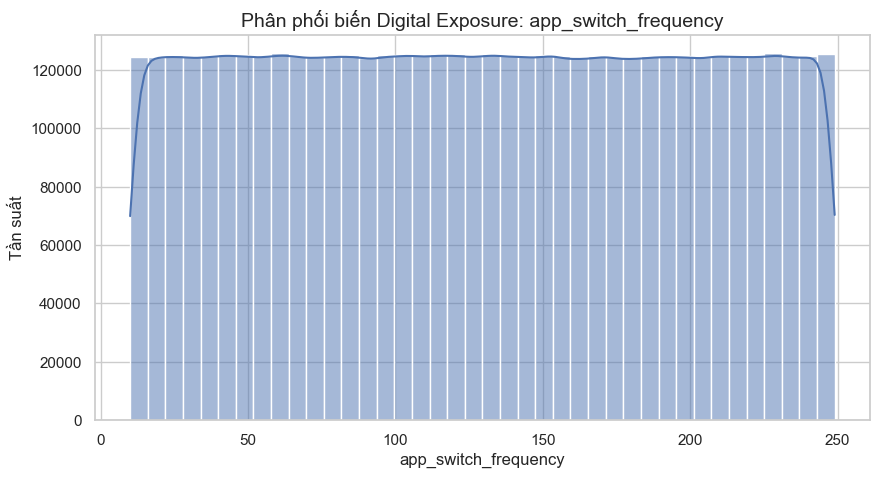

Nhận xét: Biến app_switch_frequency cho thấy đặc điểm phân phối của hành vi tiếp xúc số trong dataset.



In [62]:
# Distribution analysis for digital exposure variables

available_digital_exposure = [
    col for col in digital_exposure
    if col in df.columns
]

for col in available_digital_exposure:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Phân phối biến Digital Exposure: {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.show()

    print(f"Nhận xét: Biến {col} cho thấy đặc điểm phân phối của hành vi tiếp xúc số trong dataset.\n")

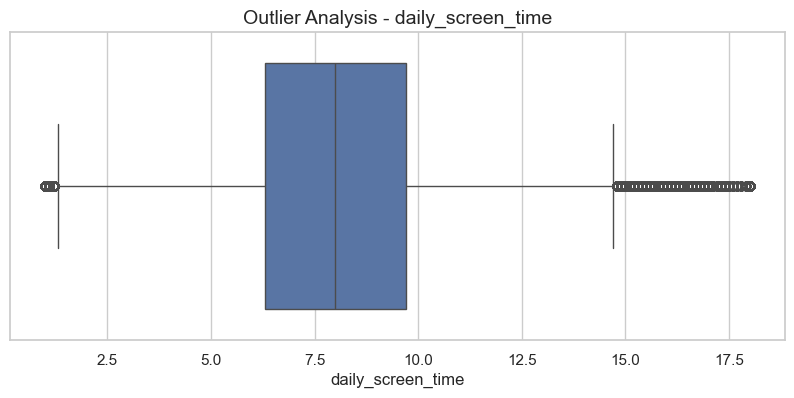

Nhận xét: Boxplot của daily_screen_time hỗ trợ nhận diện các quan sát có giá trị cao hoặc thấp bất thường.



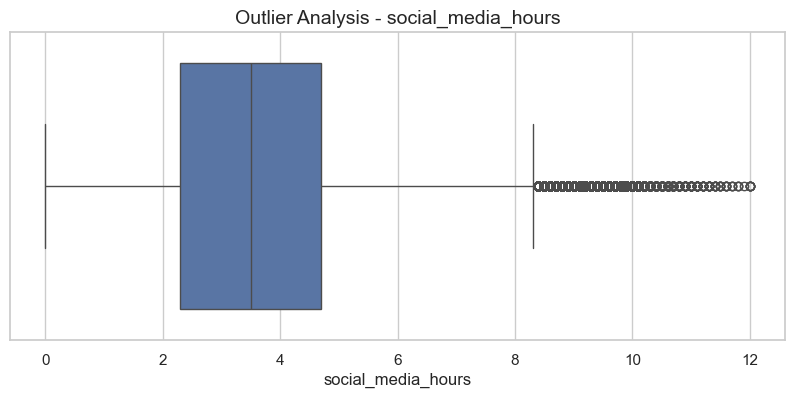

Nhận xét: Boxplot của social_media_hours hỗ trợ nhận diện các quan sát có giá trị cao hoặc thấp bất thường.



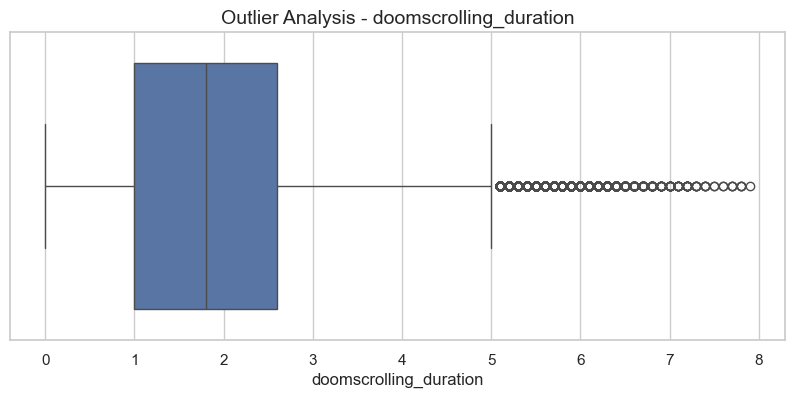

Nhận xét: Boxplot của doomscrolling_duration hỗ trợ nhận diện các quan sát có giá trị cao hoặc thấp bất thường.



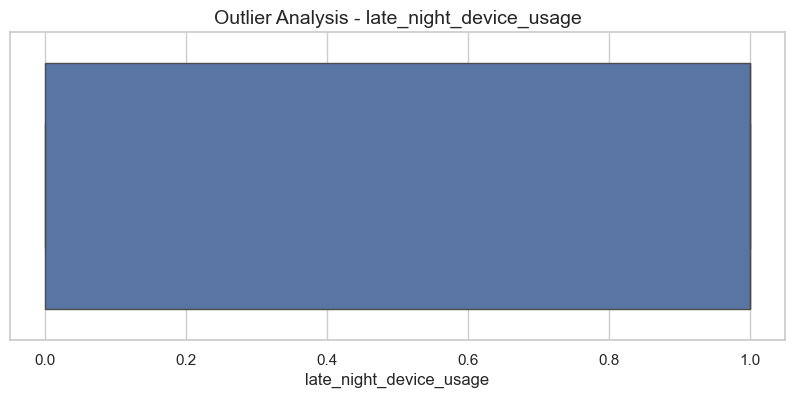

Nhận xét: Boxplot của late_night_device_usage hỗ trợ nhận diện các quan sát có giá trị cao hoặc thấp bất thường.



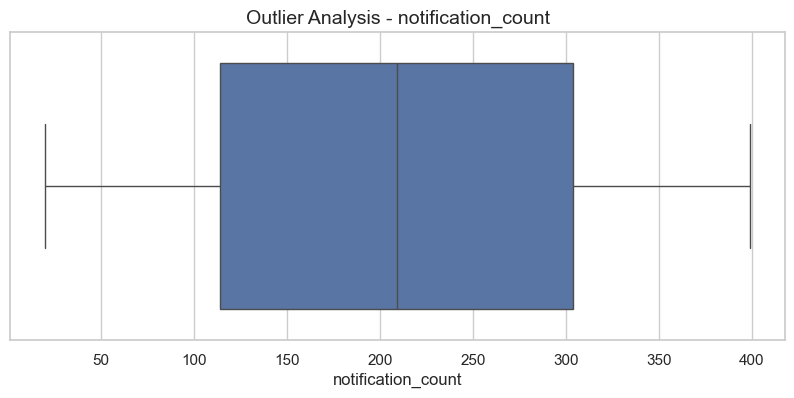

Nhận xét: Boxplot của notification_count hỗ trợ nhận diện các quan sát có giá trị cao hoặc thấp bất thường.



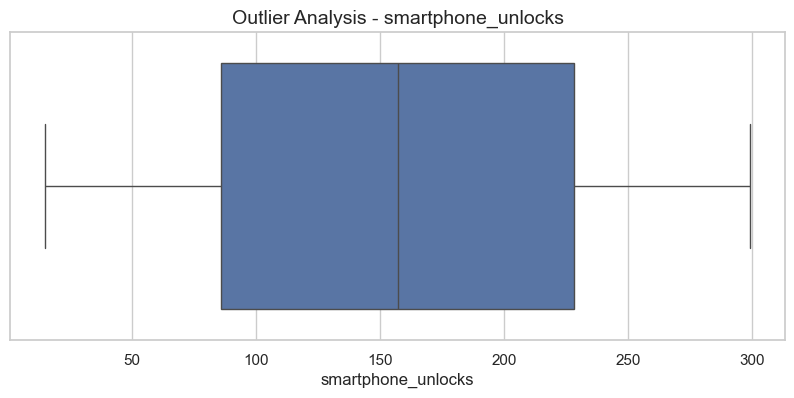

Nhận xét: Boxplot của smartphone_unlocks hỗ trợ nhận diện các quan sát có giá trị cao hoặc thấp bất thường.



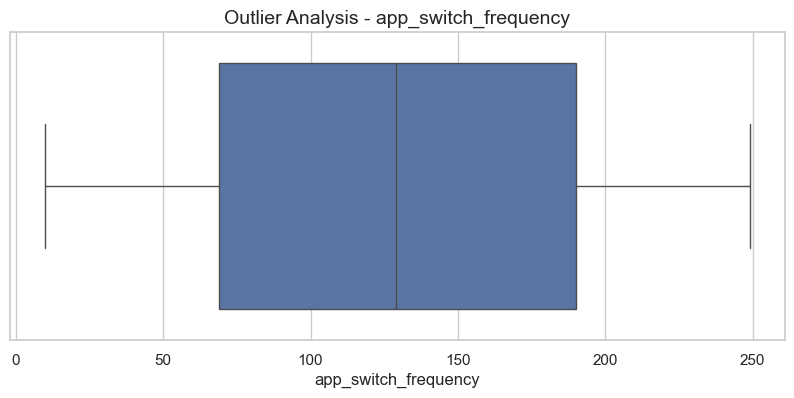

Nhận xét: Boxplot của app_switch_frequency hỗ trợ nhận diện các quan sát có giá trị cao hoặc thấp bất thường.



In [63]:
# Outlier analysis using boxplot

for col in available_digital_exposure:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Outlier Analysis - {col}")
    plt.xlabel(col)
    plt.show()

    print(f"Nhận xét: Boxplot của {col} hỗ trợ nhận diện các quan sát có giá trị cao hoặc thấp bất thường.\n")

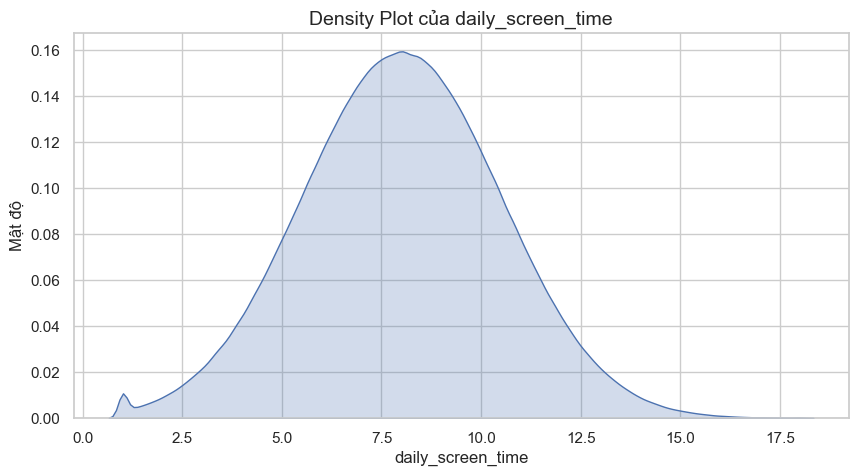

Nhận xét: Density plot cho thấy vùng giá trị tập trung nhiều nhất của biến daily_screen_time.



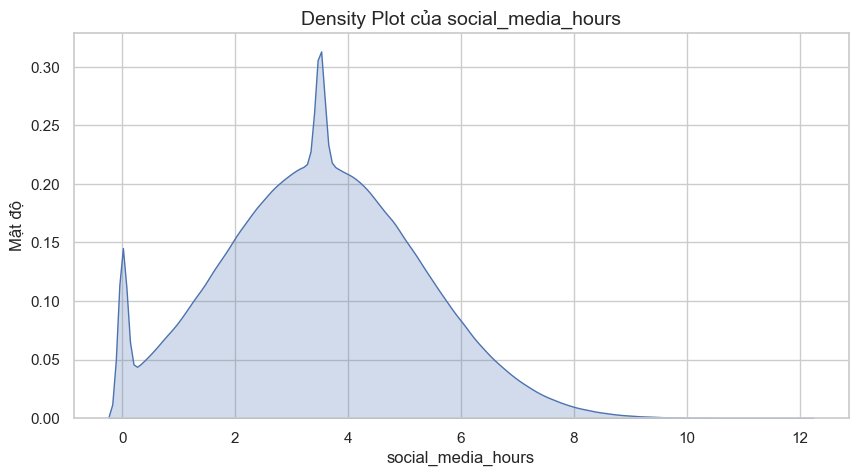

Nhận xét: Density plot cho thấy vùng giá trị tập trung nhiều nhất của biến social_media_hours.



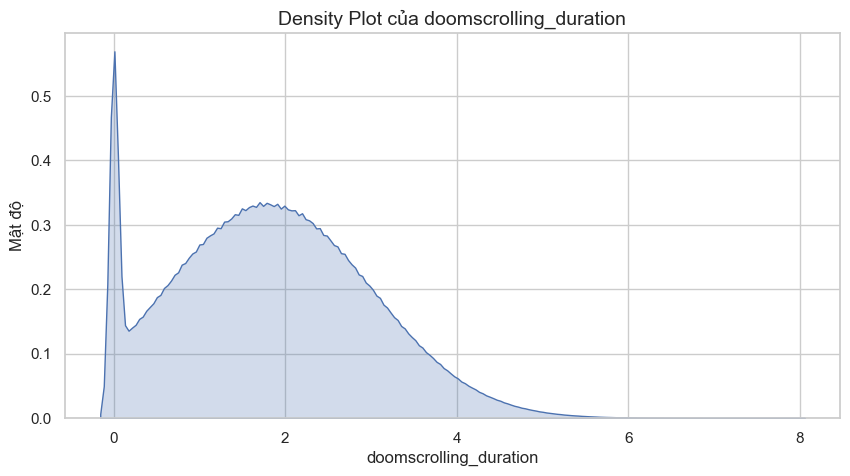

Nhận xét: Density plot cho thấy vùng giá trị tập trung nhiều nhất của biến doomscrolling_duration.



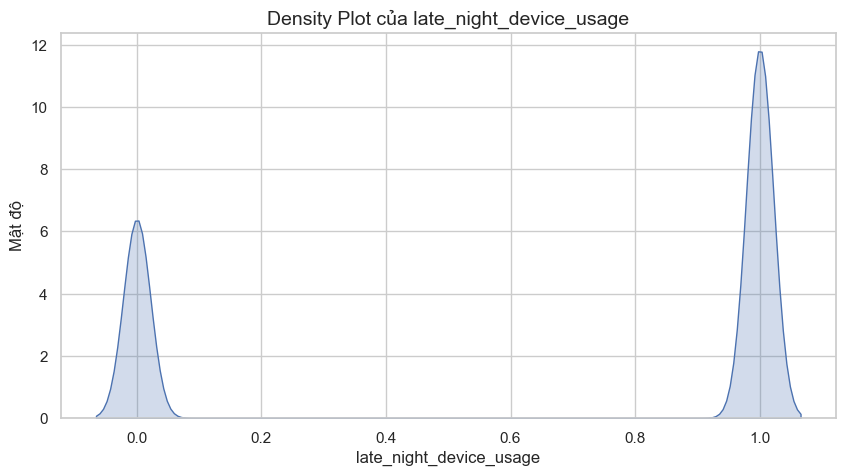

Nhận xét: Density plot cho thấy vùng giá trị tập trung nhiều nhất của biến late_night_device_usage.



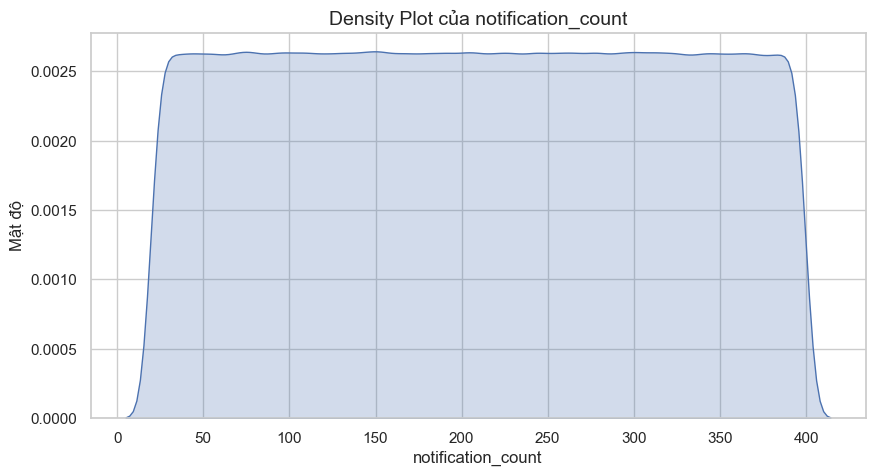

Nhận xét: Density plot cho thấy vùng giá trị tập trung nhiều nhất của biến notification_count.



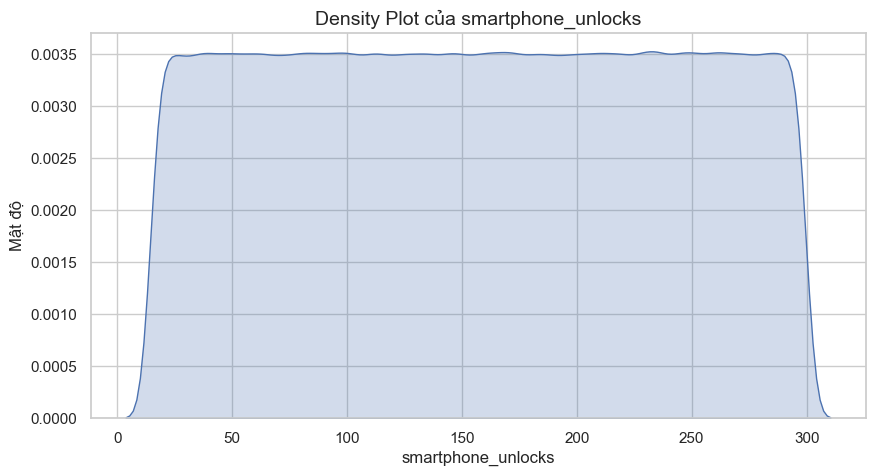

Nhận xét: Density plot cho thấy vùng giá trị tập trung nhiều nhất của biến smartphone_unlocks.



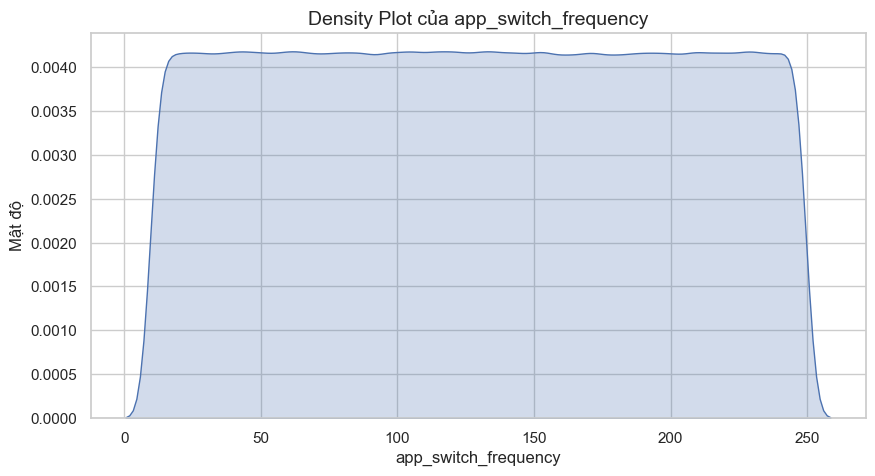

Nhận xét: Density plot cho thấy vùng giá trị tập trung nhiều nhất của biến app_switch_frequency.



In [64]:
# Density plots for digital exposure

for col in available_digital_exposure:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Density Plot của {col}")
    plt.xlabel(col)
    plt.ylabel("Mật độ")
    plt.show()

    print(f"Nhận xét: Density plot cho thấy vùng giá trị tập trung nhiều nhất của biến {col}.\n")

## Cognitive Performance Analysis

Nhóm Cognitive Performance phản ánh khả năng tập trung, hoàn thành nhiệm vụ và động lực học tập/làm việc.

Các biến gồm:
- `concentration_score`
- `distraction_frequency`
- `focus_sessions`
- `deep_work_hours`
- `task_completion_rate`
- `motivation_level`

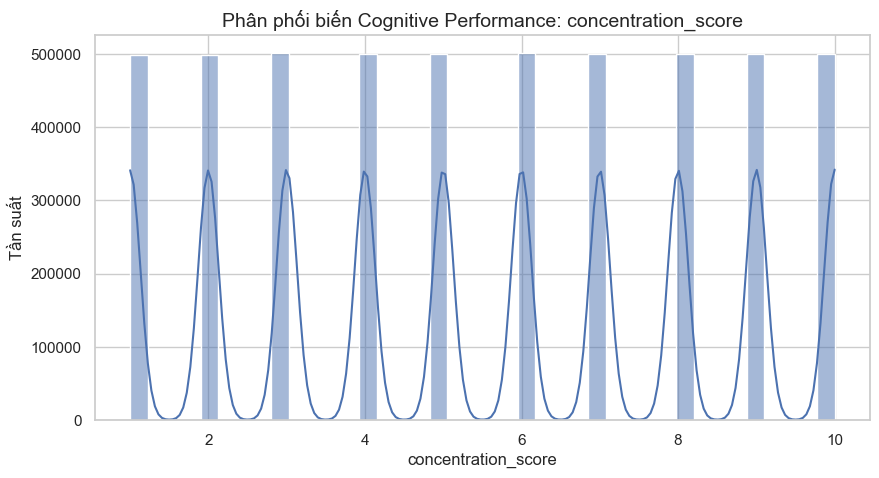

Nhận xét: Biến concentration_score phản ánh một khía cạnh của hiệu suất nhận thức và hành vi học tập/làm việc.



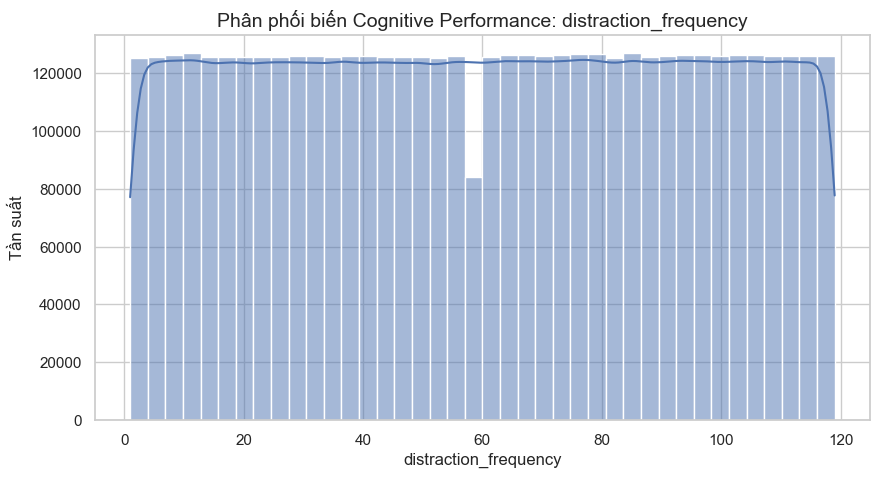

Nhận xét: Biến distraction_frequency phản ánh một khía cạnh của hiệu suất nhận thức và hành vi học tập/làm việc.



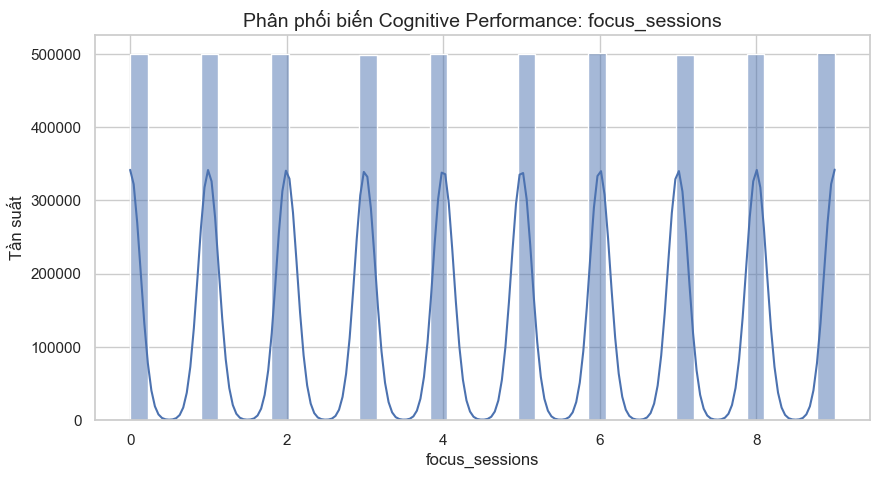

Nhận xét: Biến focus_sessions phản ánh một khía cạnh của hiệu suất nhận thức và hành vi học tập/làm việc.



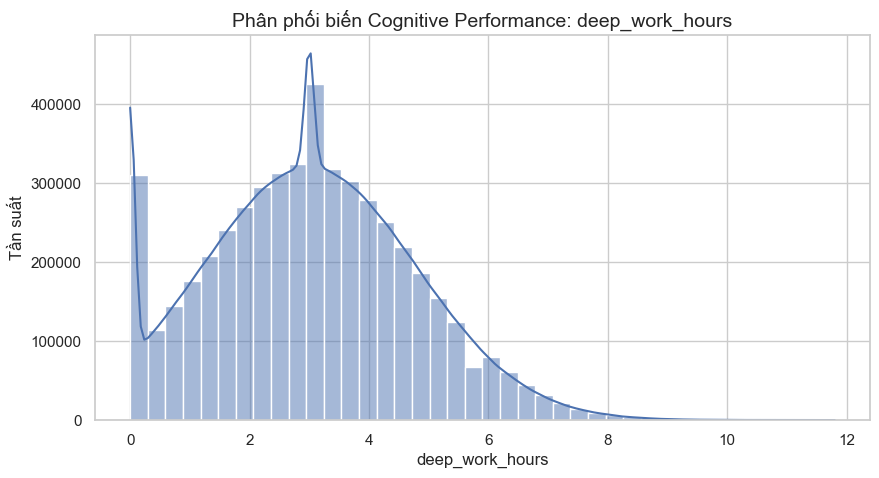

Nhận xét: Biến deep_work_hours phản ánh một khía cạnh của hiệu suất nhận thức và hành vi học tập/làm việc.



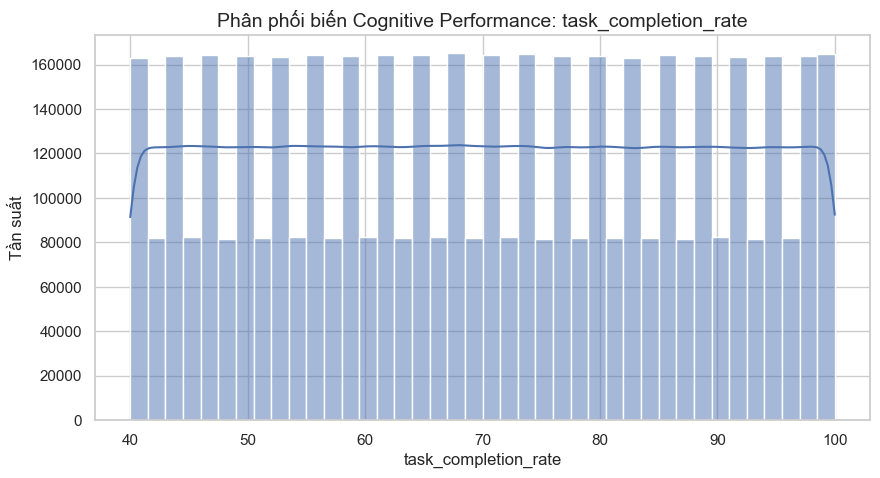

Nhận xét: Biến task_completion_rate phản ánh một khía cạnh của hiệu suất nhận thức và hành vi học tập/làm việc.



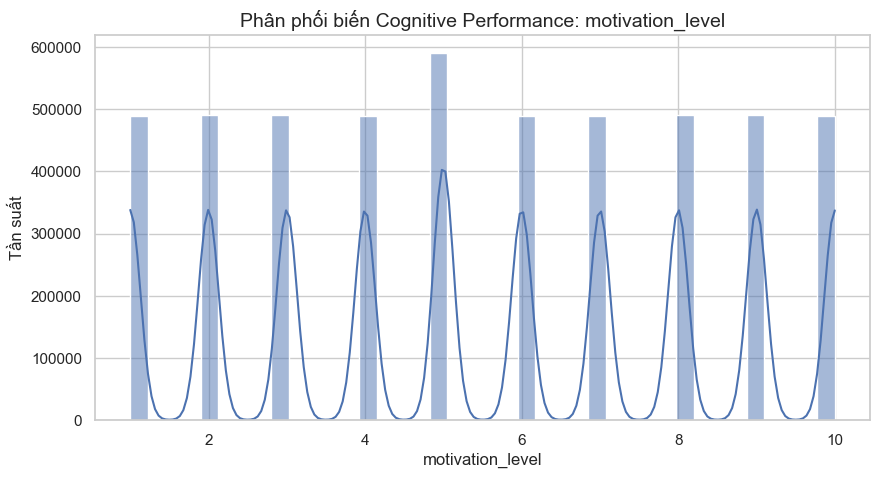

Nhận xét: Biến motivation_level phản ánh một khía cạnh của hiệu suất nhận thức và hành vi học tập/làm việc.



In [65]:
available_cognitive_performance = [
    col for col in cognitive_performance
    if col in df.columns
]

for col in available_cognitive_performance:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Phân phối biến Cognitive Performance: {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.show()

    print(f"Nhận xét: Biến {col} phản ánh một khía cạnh của hiệu suất nhận thức và hành vi học tập/làm việc.\n")

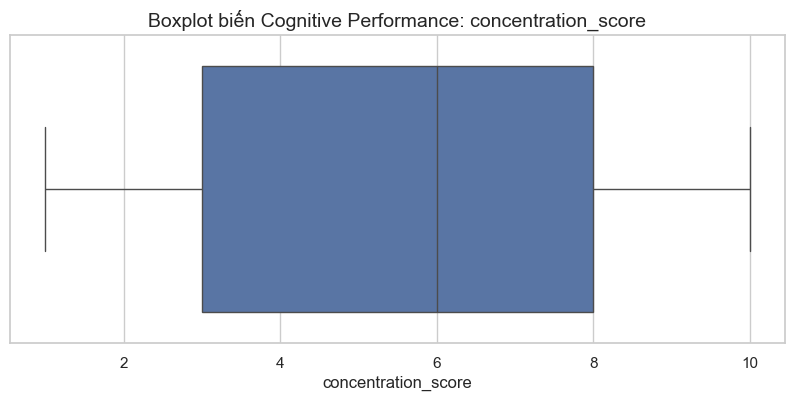

Nhận xét: Boxplot giúp đánh giá mức độ phân tán và khả năng xuất hiện giá trị bất thường của biến concentration_score.



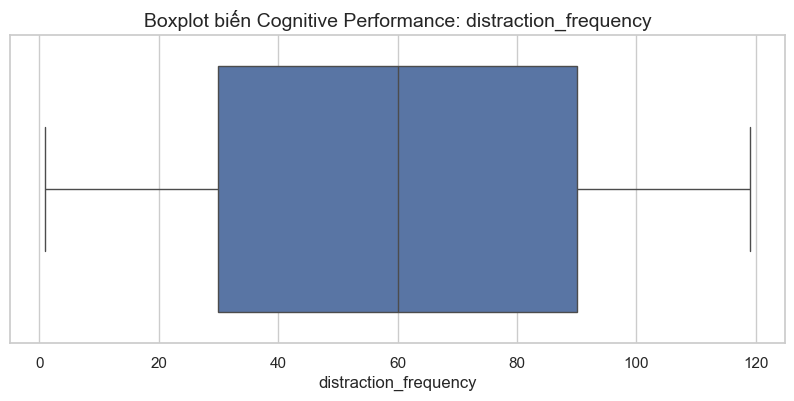

Nhận xét: Boxplot giúp đánh giá mức độ phân tán và khả năng xuất hiện giá trị bất thường của biến distraction_frequency.



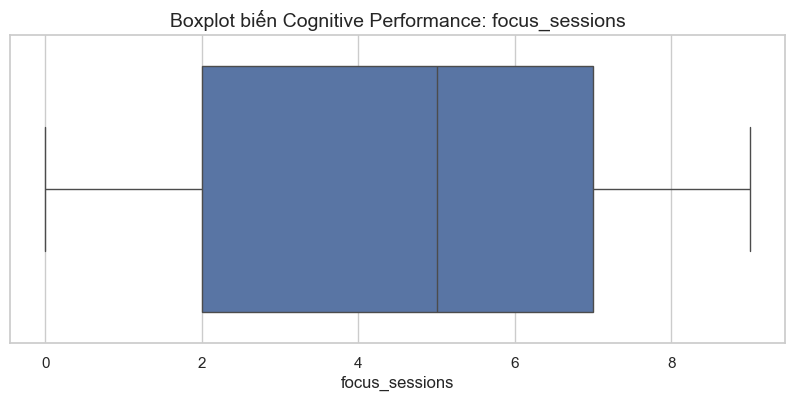

Nhận xét: Boxplot giúp đánh giá mức độ phân tán và khả năng xuất hiện giá trị bất thường của biến focus_sessions.



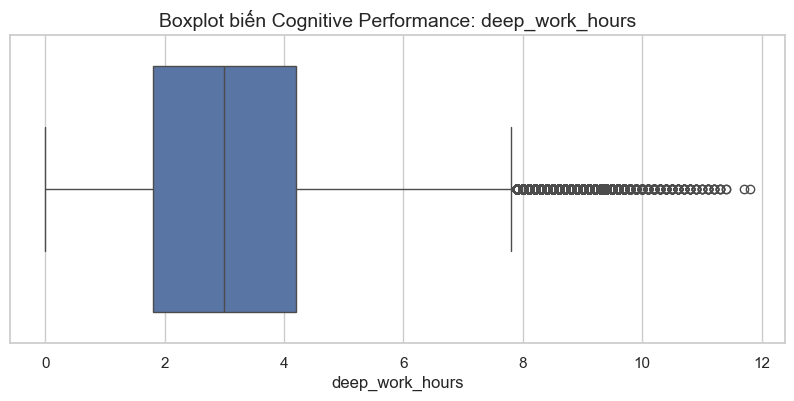

Nhận xét: Boxplot giúp đánh giá mức độ phân tán và khả năng xuất hiện giá trị bất thường của biến deep_work_hours.



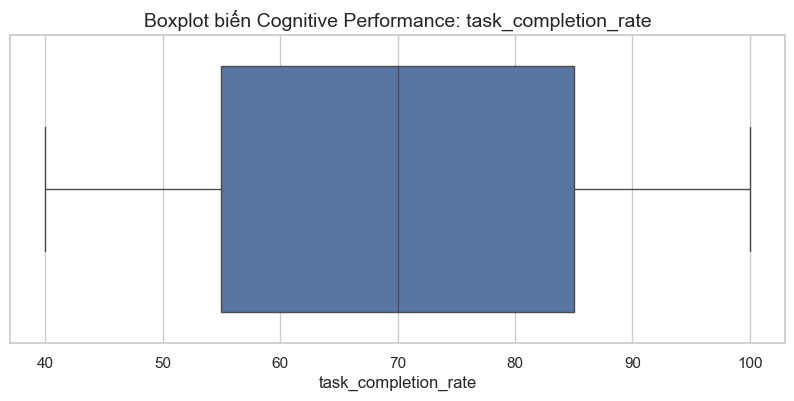

Nhận xét: Boxplot giúp đánh giá mức độ phân tán và khả năng xuất hiện giá trị bất thường của biến task_completion_rate.



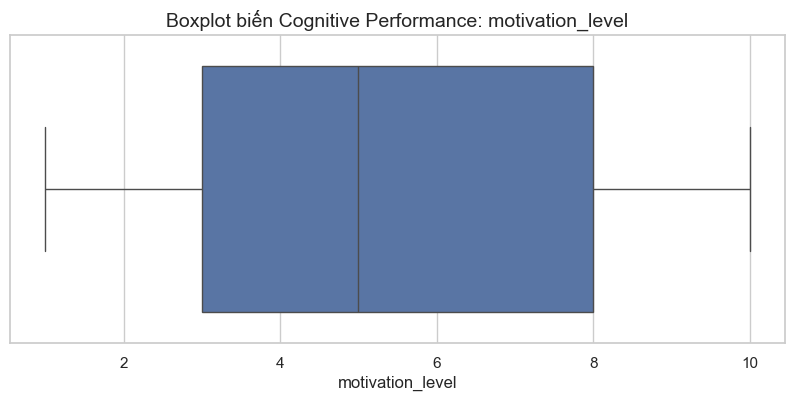

Nhận xét: Boxplot giúp đánh giá mức độ phân tán và khả năng xuất hiện giá trị bất thường của biến motivation_level.



In [66]:
# Cognitive performance boxplots

for col in available_cognitive_performance:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot biến Cognitive Performance: {col}")
    plt.xlabel(col)
    plt.show()

    print(f"Nhận xét: Boxplot giúp đánh giá mức độ phân tán và khả năng xuất hiện giá trị bất thường của biến {col}.\n")

## Sleep & Recovery Analysis

Nhóm Sleep & Recovery phản ánh khả năng phục hồi của sinh viên thông qua:

- `sleep_hours`
- `sleep_quality`

Trong nghiên cứu Digital Burnout, giấc ngủ thường được xem là yếu tố bảo vệ hoặc yếu tố liên quan đến khả năng phục hồi tâm lý.

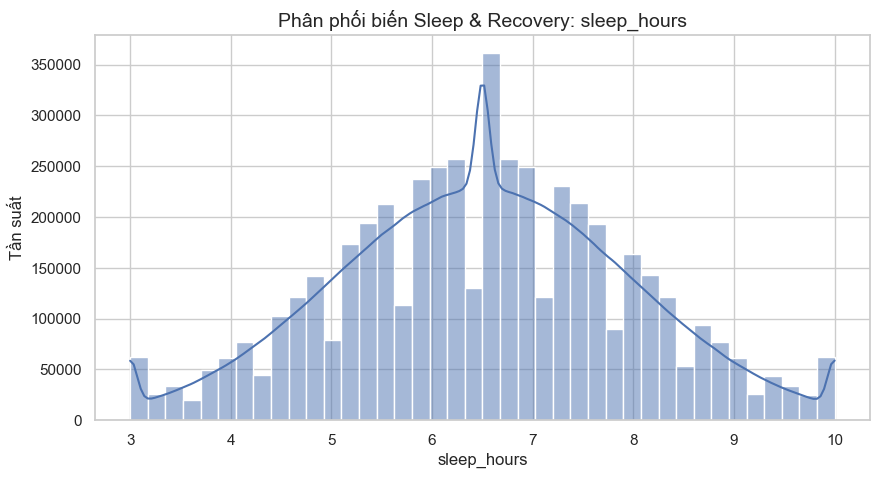

Nhận xét: Biến sleep_hours giúp quan sát đặc điểm giấc ngủ và khả năng phục hồi của sinh viên.



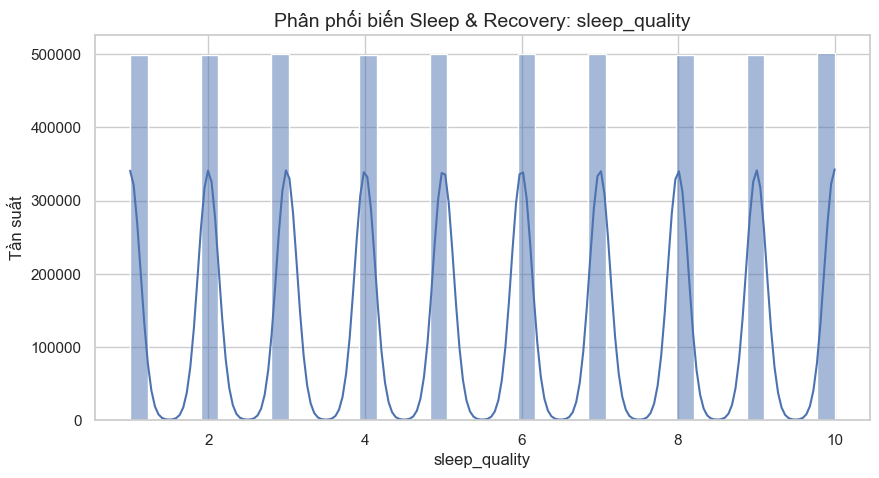

Nhận xét: Biến sleep_quality giúp quan sát đặc điểm giấc ngủ và khả năng phục hồi của sinh viên.



In [67]:
available_sleep_recovery = [
    col for col in sleep_recovery
    if col in df.columns
]

for col in available_sleep_recovery:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Phân phối biến Sleep & Recovery: {col}")
    plt.xlabel(col)
    plt.ylabel("Tần suất")
    plt.show()

    print(f"Nhận xét: Biến {col} giúp quan sát đặc điểm giấc ngủ và khả năng phục hồi của sinh viên.\n")

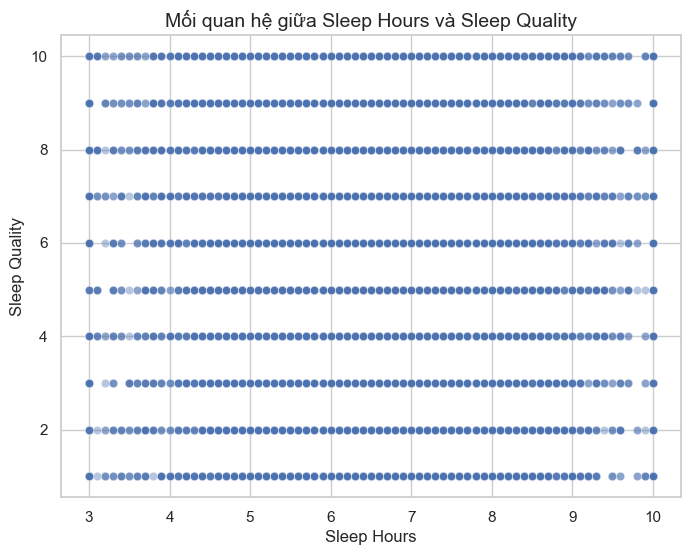

Nhận xét: Biểu đồ phân tán cho thấy xu hướng liên hệ giữa thời lượng ngủ và chất lượng giấc ngủ.


In [68]:
# Relationship between sleep_hours and sleep_quality

if all(col in df.columns for col in ["sleep_hours", "sleep_quality"]):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df.sample(min(10000, len(df)), random_state=42),
        x="sleep_hours",
        y="sleep_quality",
        alpha=0.4
    )
    plt.title("Mối quan hệ giữa Sleep Hours và Sleep Quality")
    plt.xlabel("Sleep Hours")
    plt.ylabel("Sleep Quality")
    plt.show()

    print("Nhận xét: Biểu đồ phân tán cho thấy xu hướng liên hệ giữa thời lượng ngủ và chất lượng giấc ngủ.")

## Context Analysis

Phần này phân tích các biến bối cảnh:

- `work_mode`
- `device_usage_type`

Nếu dữ liệu đã được One-Hot Encoding trong bước preprocessing, notebook sẽ phân tích các cột encoded tương ứng.

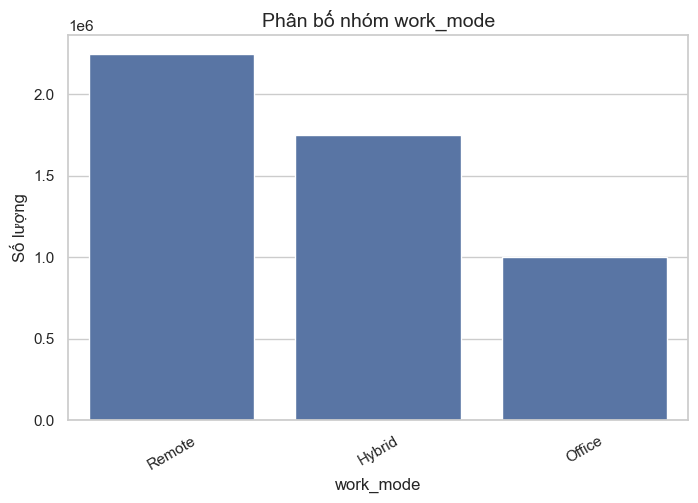

Nhận xét: Biểu đồ cho thấy tần suất xuất hiện của các nhóm trong biến work_mode.



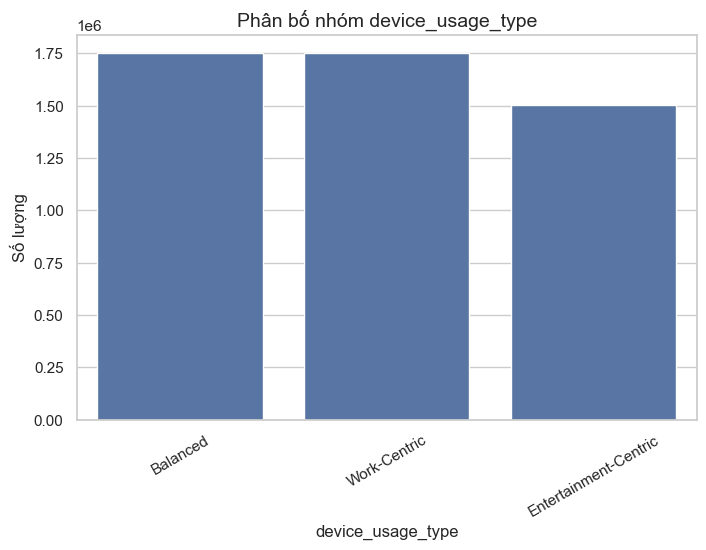

Nhận xét: Biểu đồ cho thấy tần suất xuất hiện của các nhóm trong biến device_usage_type.



In [69]:
# Context analysis for original categorical variables if available

for col in context_variables:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f"Phân bố nhóm {col}")
        plt.xlabel(col)
        plt.ylabel("Số lượng")
        plt.xticks(rotation=30)
        plt.show()

        print(f"Nhận xét: Biểu đồ cho thấy tần suất xuất hiện của các nhóm trong biến {col}.\n")

In [70]:
# Work Mode Distribution

work_mode_cols = [
    col for col in df.columns
    if col.startswith("work_mode_")
]

if work_mode_cols:

    work_mode_counts = df[work_mode_cols].sum()

    display(
        work_mode_counts.to_frame(
            name="count"
        )
    )

    plt.figure(figsize=(8,5))

    sns.barplot(
        x=work_mode_counts.values,
        y=work_mode_counts.index
    )

    plt.title("Phân bố Work Mode")
    plt.xlabel("Count")
    plt.ylabel("Work Mode")

    plt.show()

    print(
        "Nhận xét: Chế độ học tập/làm việc được phân bổ khác nhau trong dataset."
    )

In [71]:
device_usage_cols = [
    col for col in df.columns
    if col.startswith("device_usage_type_")
]

if device_usage_cols:

    device_usage_counts = df[device_usage_cols].sum()

    display(
        device_usage_counts.to_frame(
            name="count"
        )
    )

    plt.figure(figsize=(8,5))

    sns.barplot(
        x=device_usage_counts.values,
        y=device_usage_counts.index
    )

    plt.title("Phân bố Device Usage Type")
    plt.xlabel("Count")
    plt.ylabel("Device Usage Type")

    plt.show()

    print(
        "Nhận xét: Các nhóm hành vi sử dụng thiết bị có tỷ lệ xuất hiện khác nhau trong dataset."
    )

## Relationship Analysis

Phần này phân tích các mối quan hệ chính:

1. `burnout_risk` với hành vi sử dụng thiết bị.
2. `burnout_risk` với giấc ngủ.
3. `burnout_risk` với hiệu suất nhận thức.
4. `productivity_score` với hiệu suất nhận thức.

Các biểu đồ sử dụng sample nếu dataset quá lớn nhằm tối ưu hiệu năng hiển thị.

In [72]:
# Create sample for scatter plots

plot_sample = df.sample(min(10000, len(df)), random_state=42)

print(f"Số dòng dùng để trực quan hóa scatter plot: {len(plot_sample):,}")

Số dòng dùng để trực quan hóa scatter plot: 10,000


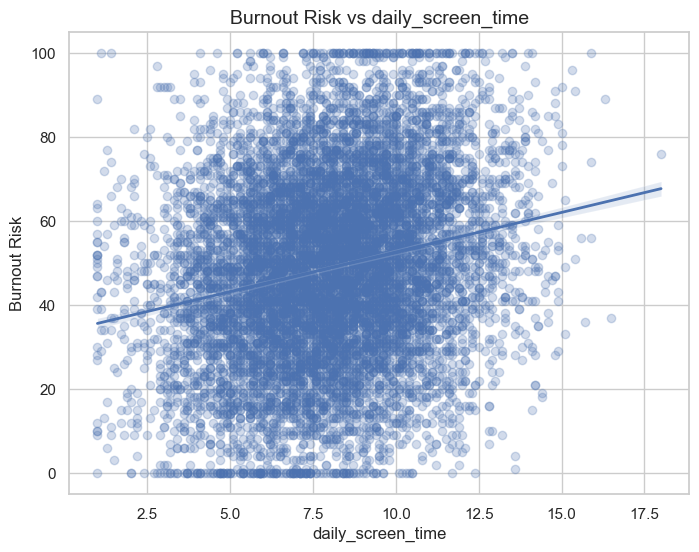

Nhận xét: Biểu đồ kiểm tra xu hướng liên hệ giữa daily_screen_time và burnout_risk.



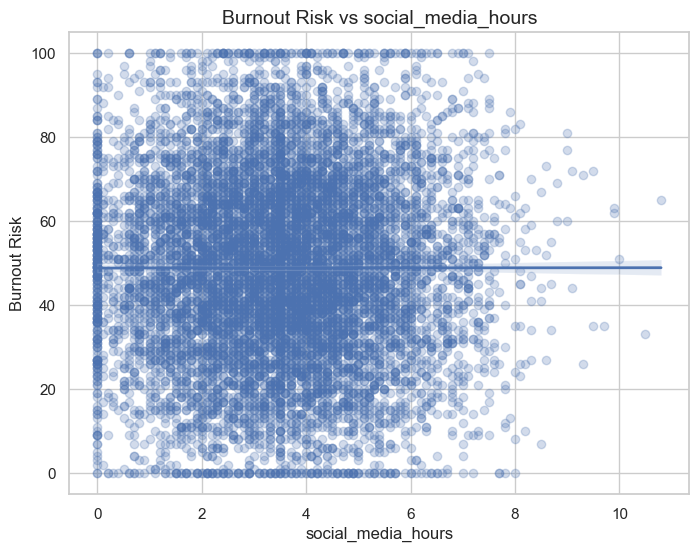

Nhận xét: Biểu đồ kiểm tra xu hướng liên hệ giữa social_media_hours và burnout_risk.



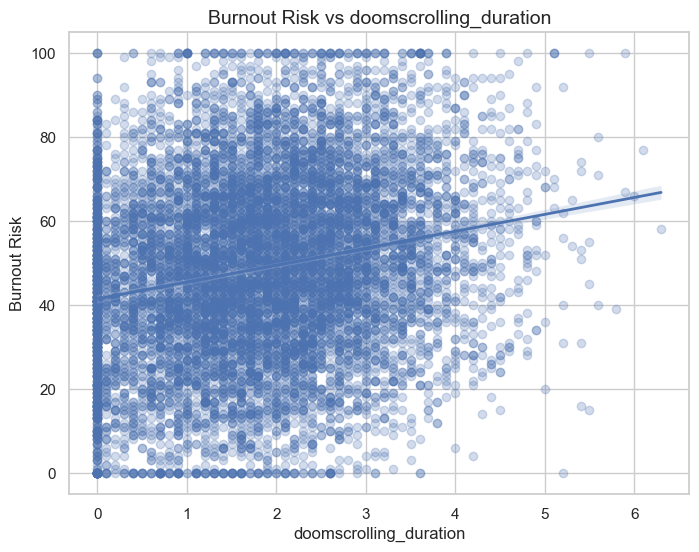

Nhận xét: Biểu đồ kiểm tra xu hướng liên hệ giữa doomscrolling_duration và burnout_risk.



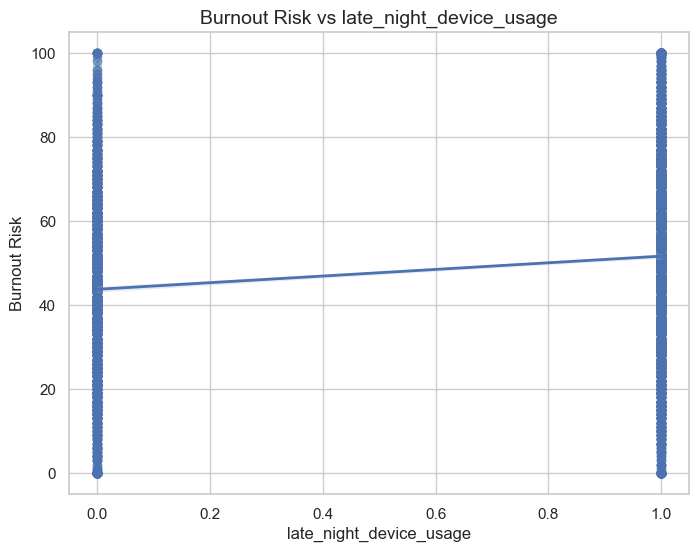

Nhận xét: Biểu đồ kiểm tra xu hướng liên hệ giữa late_night_device_usage và burnout_risk.



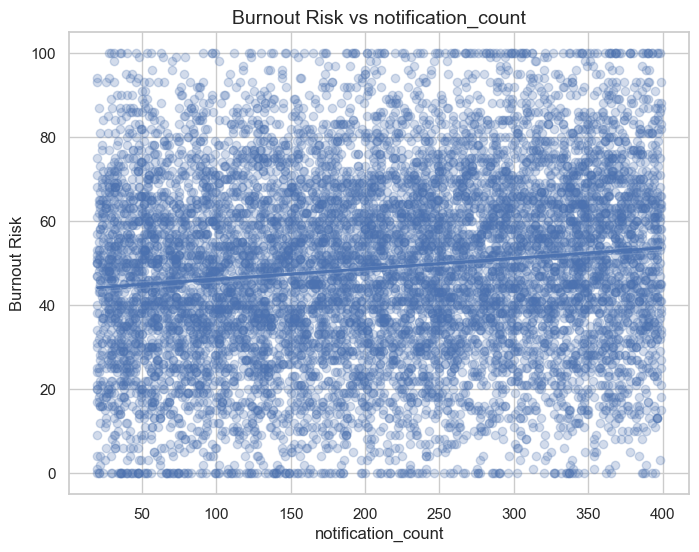

Nhận xét: Biểu đồ kiểm tra xu hướng liên hệ giữa notification_count và burnout_risk.



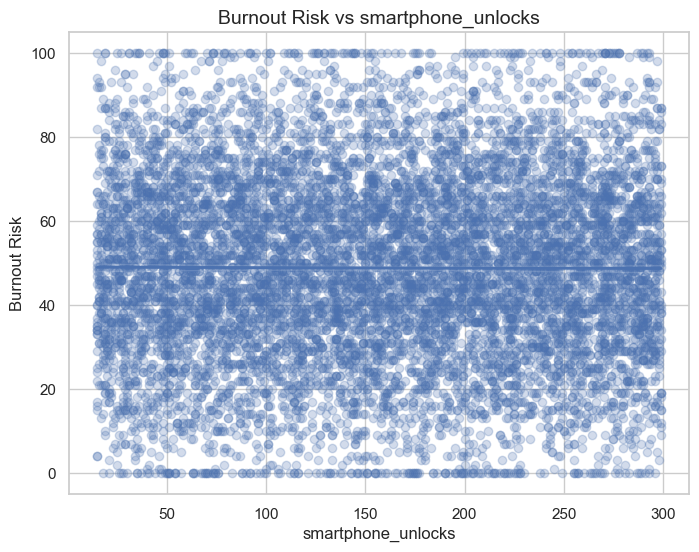

Nhận xét: Biểu đồ kiểm tra xu hướng liên hệ giữa smartphone_unlocks và burnout_risk.



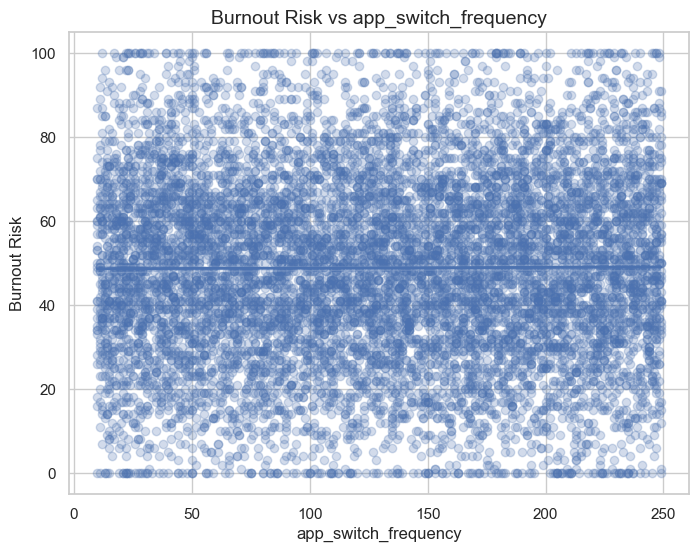

Nhận xét: Biểu đồ kiểm tra xu hướng liên hệ giữa app_switch_frequency và burnout_risk.



In [73]:
# burnout_risk vs digital behavior

if "burnout_risk" in df.columns:
    for col in available_digital_exposure:
        plt.figure(figsize=(8, 6))
        sns.regplot(
            data=plot_sample,
            x=col,
            y="burnout_risk",
            scatter_kws={"alpha": 0.25},
            line_kws={"linewidth": 2}
        )
        plt.title(f"Burnout Risk vs {col}")
        plt.xlabel(col)
        plt.ylabel("Burnout Risk")
        plt.show()

        print(f"Nhận xét: Biểu đồ kiểm tra xu hướng liên hệ giữa {col} và burnout_risk.\n")

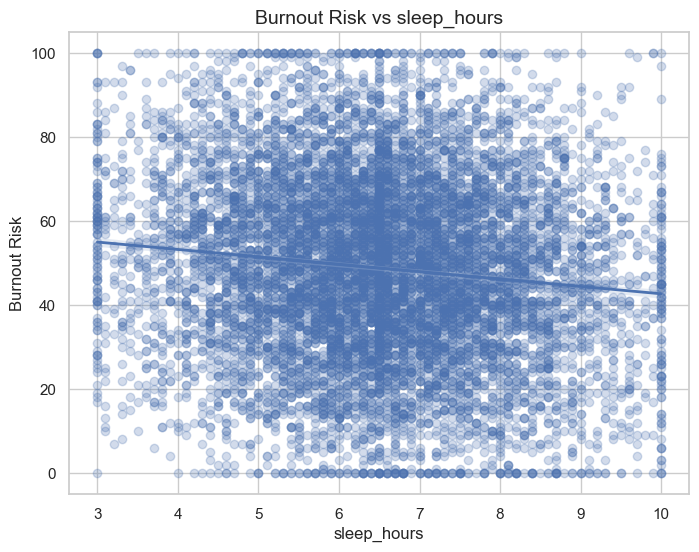

Nhận xét: Biểu đồ cho thấy xu hướng liên hệ giữa sleep_hours và mức độ burnout.



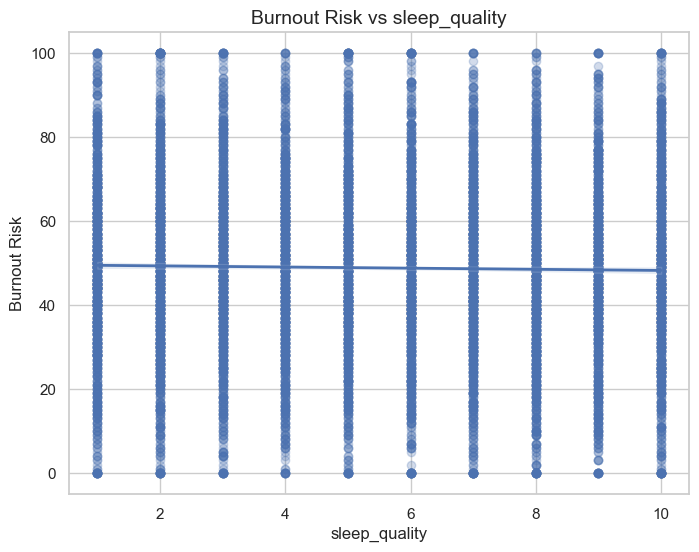

Nhận xét: Biểu đồ cho thấy xu hướng liên hệ giữa sleep_quality và mức độ burnout.



In [74]:
# burnout_risk vs sleep

if "burnout_risk" in df.columns:
    for col in available_sleep_recovery:
        plt.figure(figsize=(8, 6))
        sns.regplot(
            data=plot_sample,
            x=col,
            y="burnout_risk",
            scatter_kws={"alpha": 0.25},
            line_kws={"linewidth": 2}
        )
        plt.title(f"Burnout Risk vs {col}")
        plt.xlabel(col)
        plt.ylabel("Burnout Risk")
        plt.show()

        print(f"Nhận xét: Biểu đồ cho thấy xu hướng liên hệ giữa {col} và mức độ burnout.\n")

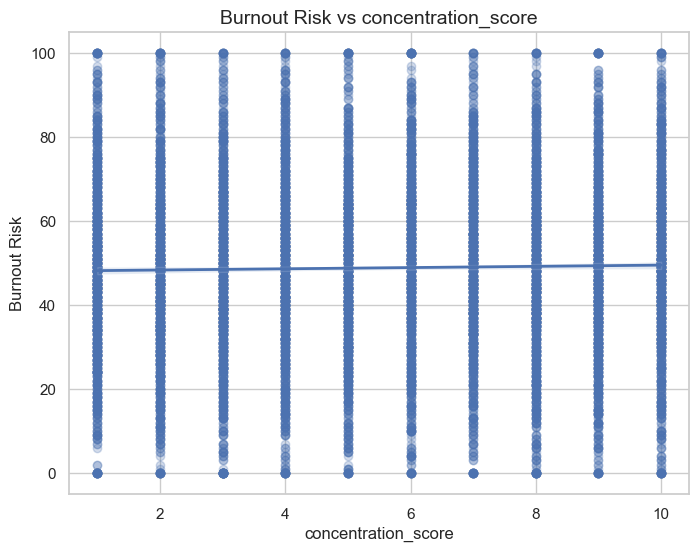

Nhận xét: Biểu đồ giúp đánh giá liệu concentration_score có xu hướng tăng/giảm cùng burnout_risk hay không.



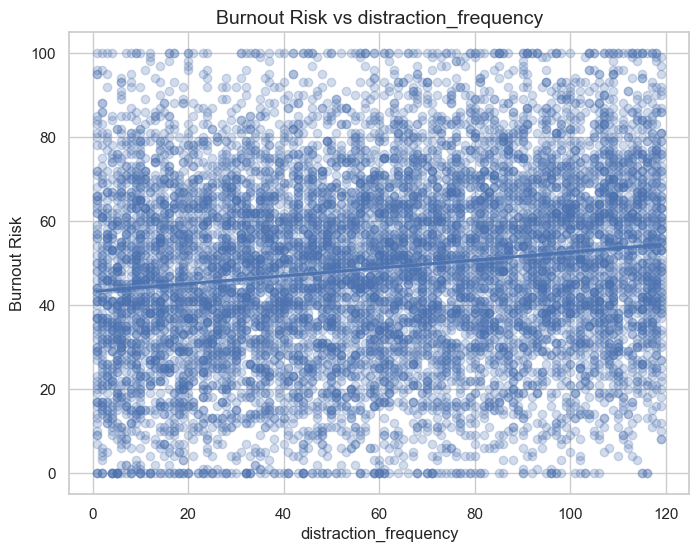

Nhận xét: Biểu đồ giúp đánh giá liệu distraction_frequency có xu hướng tăng/giảm cùng burnout_risk hay không.



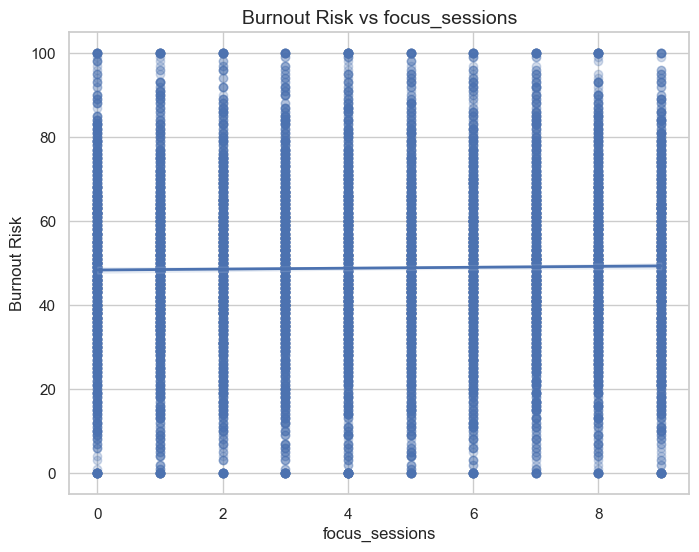

Nhận xét: Biểu đồ giúp đánh giá liệu focus_sessions có xu hướng tăng/giảm cùng burnout_risk hay không.



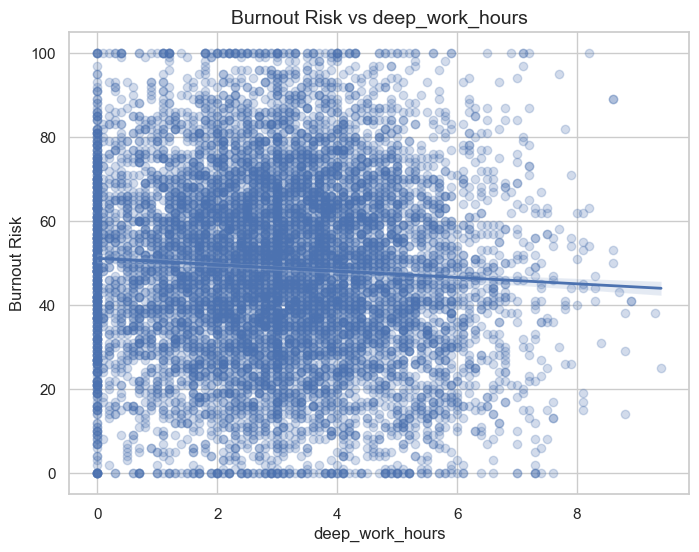

Nhận xét: Biểu đồ giúp đánh giá liệu deep_work_hours có xu hướng tăng/giảm cùng burnout_risk hay không.



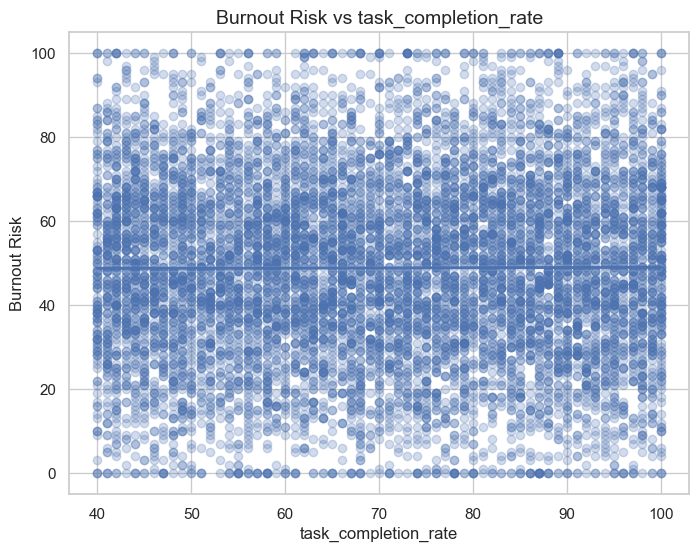

Nhận xét: Biểu đồ giúp đánh giá liệu task_completion_rate có xu hướng tăng/giảm cùng burnout_risk hay không.



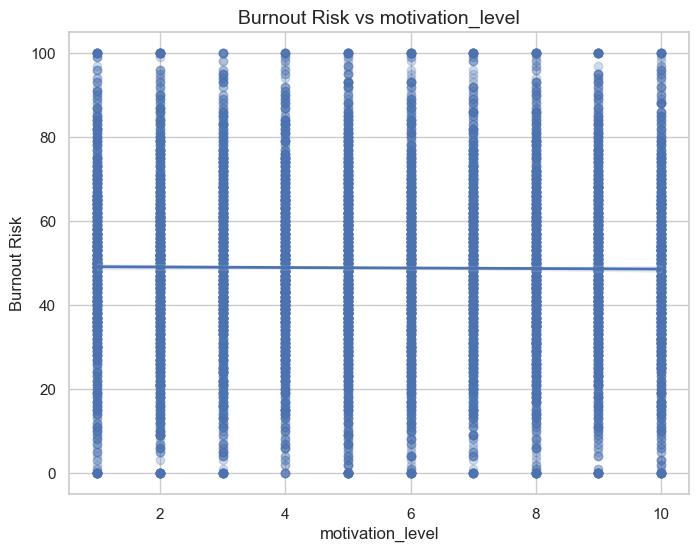

Nhận xét: Biểu đồ giúp đánh giá liệu motivation_level có xu hướng tăng/giảm cùng burnout_risk hay không.



In [75]:
# burnout_risk vs cognitive performance

if "burnout_risk" in df.columns:
    for col in available_cognitive_performance:
        plt.figure(figsize=(8, 6))
        sns.regplot(
            data=plot_sample,
            x=col,
            y="burnout_risk",
            scatter_kws={"alpha": 0.25},
            line_kws={"linewidth": 2}
        )
        plt.title(f"Burnout Risk vs {col}")
        plt.xlabel(col)
        plt.ylabel("Burnout Risk")
        plt.show()

        print(f"Nhận xét: Biểu đồ giúp đánh giá liệu {col} có xu hướng tăng/giảm cùng burnout_risk hay không.\n")

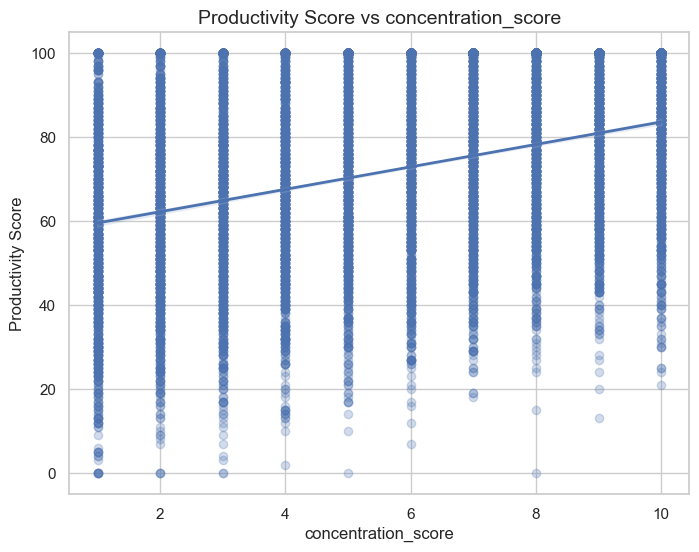

Nhận xét: Biểu đồ cho thấy mối liên hệ giữa concentration_score và năng suất học tập/làm việc.



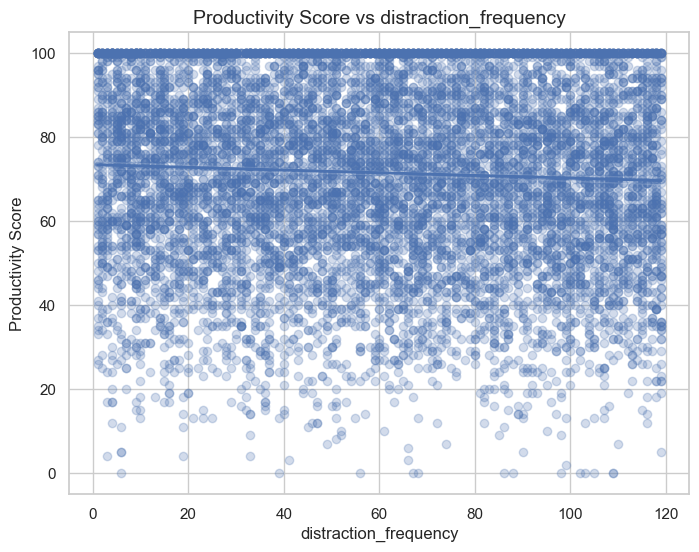

Nhận xét: Biểu đồ cho thấy mối liên hệ giữa distraction_frequency và năng suất học tập/làm việc.



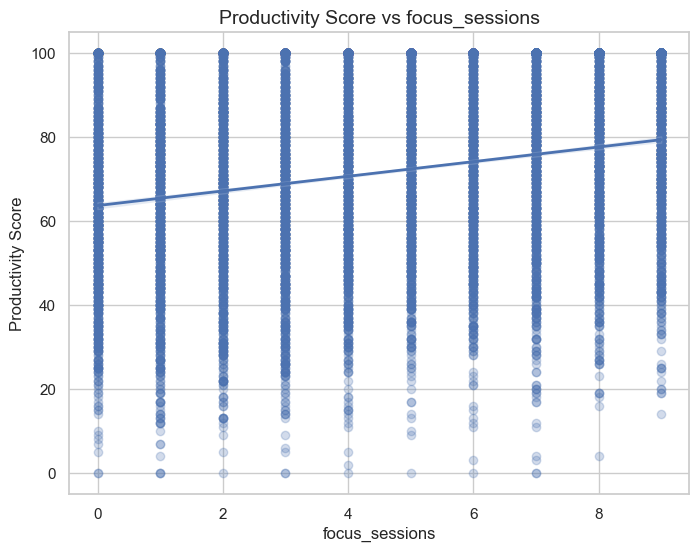

Nhận xét: Biểu đồ cho thấy mối liên hệ giữa focus_sessions và năng suất học tập/làm việc.



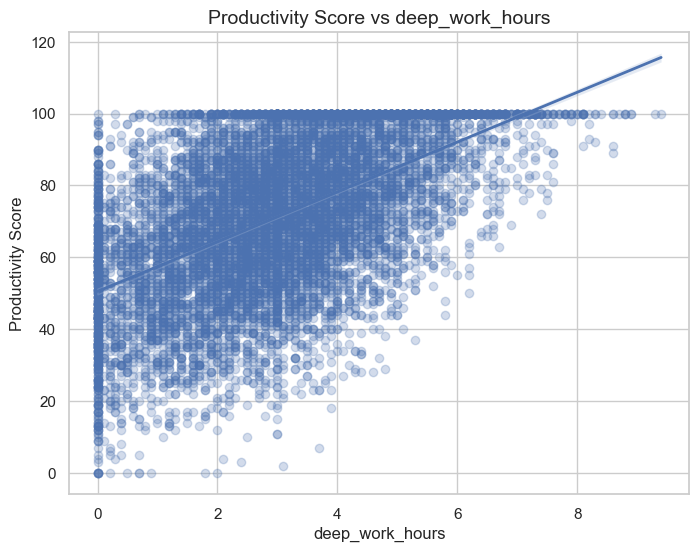

Nhận xét: Biểu đồ cho thấy mối liên hệ giữa deep_work_hours và năng suất học tập/làm việc.



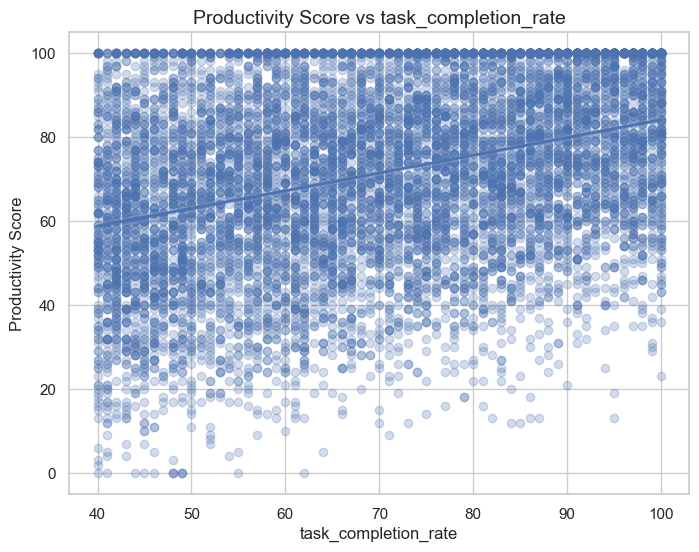

Nhận xét: Biểu đồ cho thấy mối liên hệ giữa task_completion_rate và năng suất học tập/làm việc.



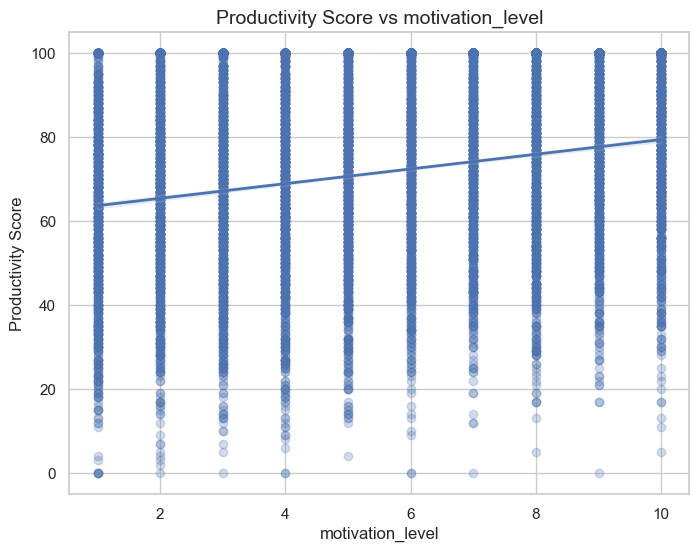

Nhận xét: Biểu đồ cho thấy mối liên hệ giữa motivation_level và năng suất học tập/làm việc.



In [76]:
# productivity_score vs cognitive performance

if "productivity_score" in df.columns:
    for col in available_cognitive_performance:
        plt.figure(figsize=(8, 6))
        sns.regplot(
            data=plot_sample,
            x=col,
            y="productivity_score",
            scatter_kws={"alpha": 0.25},
            line_kws={"linewidth": 2}
        )
        plt.title(f"Productivity Score vs {col}")
        plt.xlabel(col)
        plt.ylabel("Productivity Score")
        plt.show()

        print(f"Nhận xét: Biểu đồ cho thấy mối liên hệ giữa {col} và năng suất học tập/làm việc.\n")

## Correlation Analysis

Phần này sử dụng hai hệ số tương quan:

### Pearson Correlation
Đo lường mối quan hệ tuyến tính giữa hai biến định lượng.

### Spearman Correlation
Đo lường mối quan hệ đơn điệu, ít nhạy hơn với phân phối không chuẩn hoặc outlier.

Mục tiêu là xác định các nhóm biến có liên hệ mạnh với:
- `burnout_risk`
- `productivity_score`

In [77]:
# Select numeric variables for correlation analysis

numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

eda_numeric_columns = [
    col for col in (
        target_variables
        + burnout_symptoms
        + digital_exposure
        + cognitive_performance
        + sleep_recovery
    )
    if col in numeric_columns
]

print("Số biến định lượng dùng cho correlation analysis:", len(eda_numeric_columns))
print(eda_numeric_columns)

Số biến định lượng dùng cho correlation analysis: 20
['burnout_risk', 'productivity_score', 'emotional_exhaustion', 'stress_level', 'mental_fatigue', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'late_night_device_usage', 'notification_count', 'smartphone_unlocks', 'app_switch_frequency', 'concentration_score', 'distraction_frequency', 'focus_sessions', 'deep_work_hours', 'task_completion_rate', 'motivation_level', 'sleep_hours', 'sleep_quality']


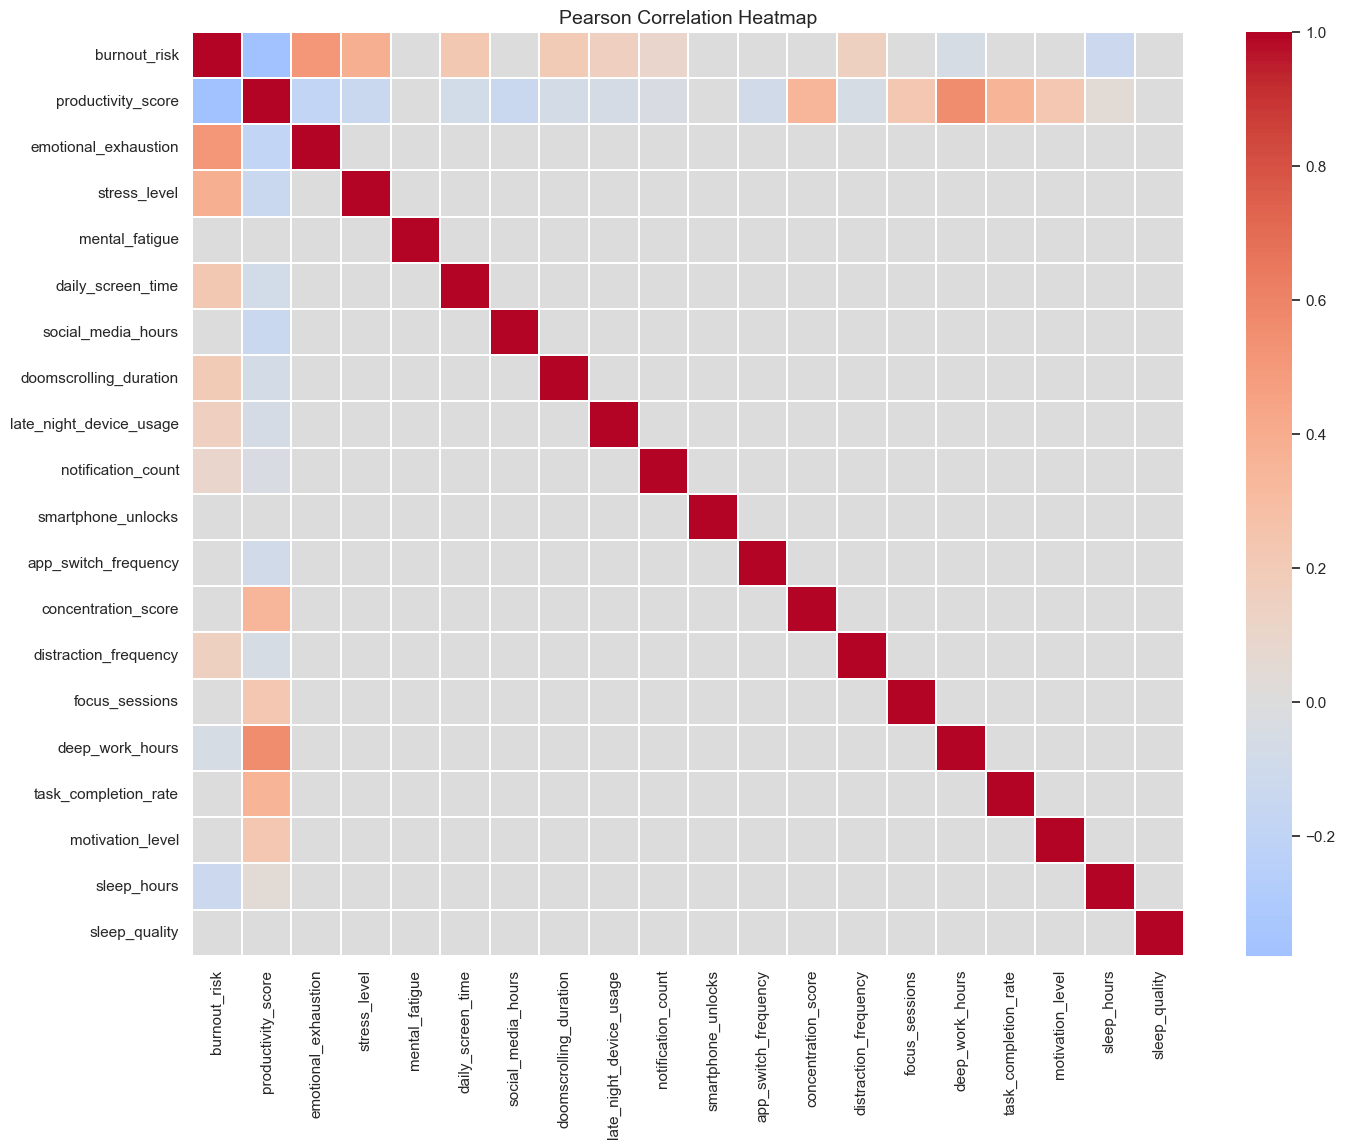

Nhận xét: Heatmap Pearson cho thấy mức độ liên hệ tuyến tính giữa các biến nghiên cứu.


In [78]:
# Pearson correlation matrix

pearson_corr = df[eda_numeric_columns].corr(method="pearson")

plt.figure(figsize=(16, 12))
sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.3
)

plt.title("Pearson Correlation Heatmap")
plt.show()

print("Nhận xét: Heatmap Pearson cho thấy mức độ liên hệ tuyến tính giữa các biến nghiên cứu.")

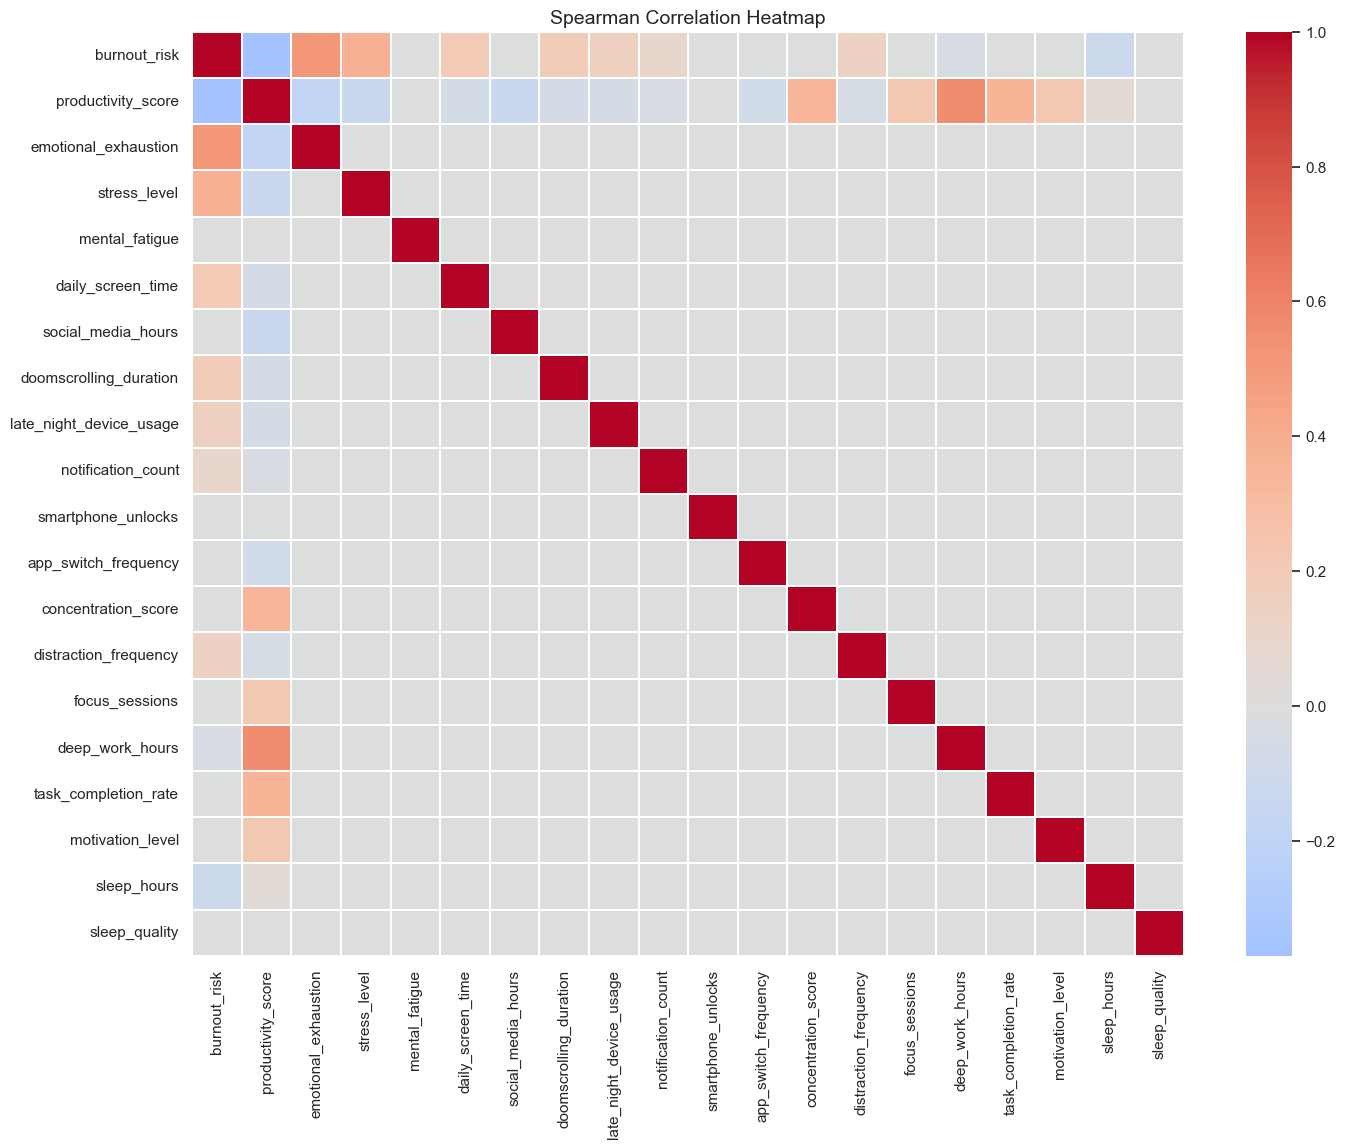

Nhận xét: Heatmap Spearman giúp đánh giá quan hệ đơn điệu giữa các biến, phù hợp khi dữ liệu không hoàn toàn tuyến tính.


In [79]:
# Spearman correlation matrix

spearman_corr = df[eda_numeric_columns].corr(method="spearman")

plt.figure(figsize=(16, 12))
sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.3
)

plt.title("Spearman Correlation Heatmap")
plt.show()

print("Nhận xét: Heatmap Spearman giúp đánh giá quan hệ đơn điệu giữa các biến, phù hợp khi dữ liệu không hoàn toàn tuyến tính.")

Tương quan với burnout_risk:


,pearson_corr,spearman_corr,abs_pearson_corr
emotional_exhaustion,0.511981,0.509398,0.511981
stress_level,0.382824,0.376978,0.382824
productivity_score,-0.377971,-0.371095,0.377971
daily_screen_time,0.220783,0.210659,0.220783
doomscrolling_duration,0.200315,0.192633,0.200315
late_night_device_usage,0.158050,0.154407,0.158050
distraction_frequency,0.152152,0.148415,0.152152
sleep_hours,-0.129446,-0.123721,0.129446
notification_count,0.096691,0.094314,0.096691
deep_work_hours,-0.046383,-0.040238,0.046383


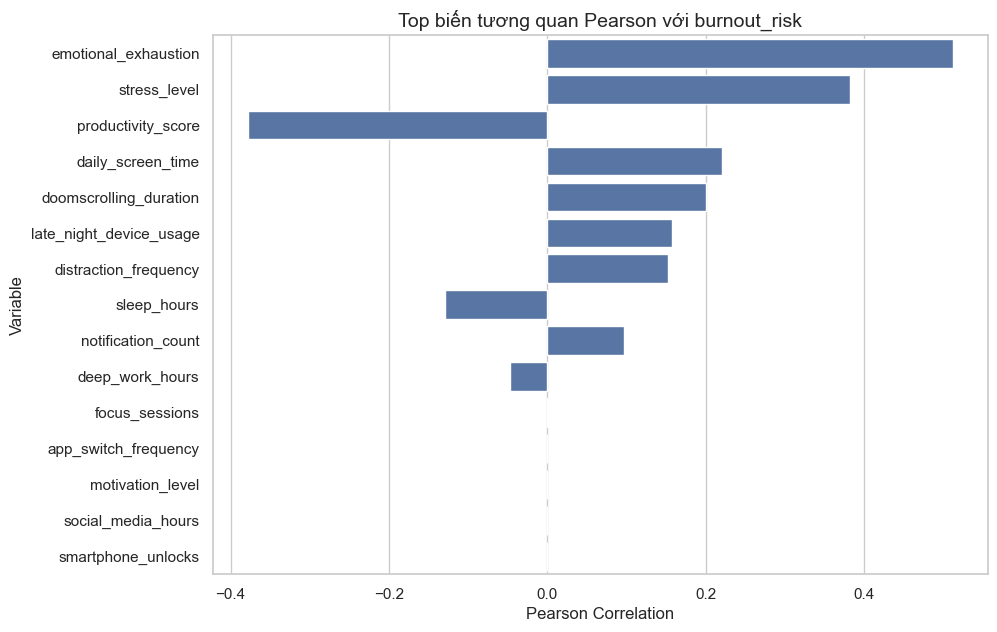

Nhận xét: Bảng và biểu đồ trên cho thấy các biến có liên hệ mạnh nhất với burnout_risk.

Tương quan với productivity_score:


,pearson_corr,spearman_corr,abs_pearson_corr
deep_work_hours,0.554573,0.556077,0.554573
burnout_risk,-0.377971,-0.371095,0.377971
task_completion_rate,0.355764,0.353570,0.355764
concentration_score,0.347326,0.345042,0.347326
focus_sessions,0.230093,0.227663,0.230093
motivation_level,0.228960,0.226453,0.228960
emotional_exhaustion,-0.181940,-0.180020,0.181940
social_media_hours,-0.140029,-0.135305,0.140029
stress_level,-0.135014,-0.133452,0.135014
app_switch_frequency,-0.082157,-0.081262,0.082157


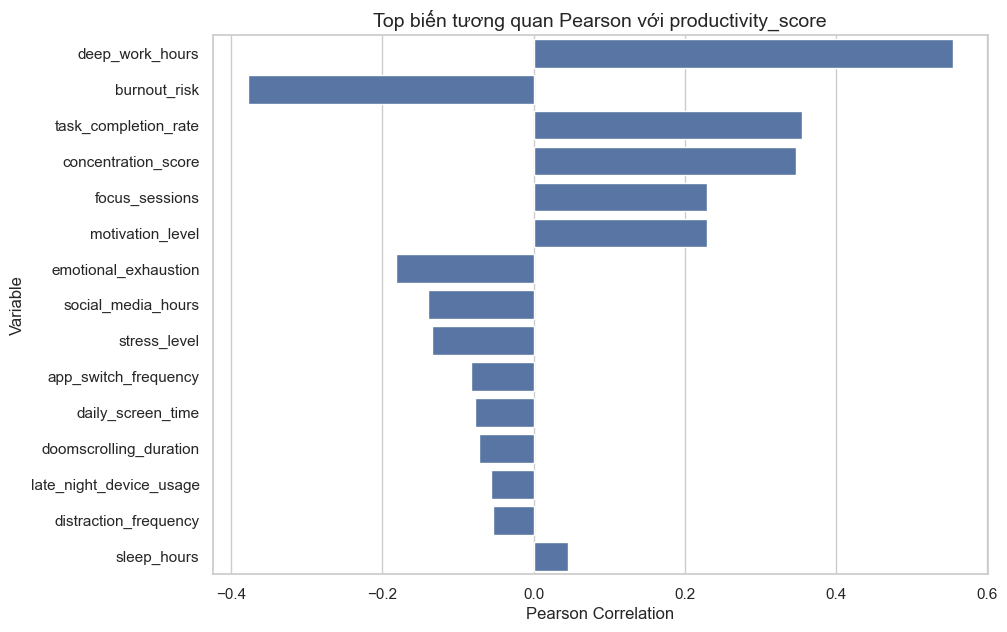

Nhận xét: Bảng và biểu đồ trên cho thấy các biến có liên hệ mạnh nhất với productivity_score.



In [80]:
# Correlation with burnout_risk and productivity_score

correlation_targets = [
    col for col in ["burnout_risk", "productivity_score"]
    if col in pearson_corr.columns
]

for target in correlation_targets:
    corr_table = pd.DataFrame({
        "pearson_corr": pearson_corr[target],
        "spearman_corr": spearman_corr[target]
    }).drop(index=target, errors="ignore")

    corr_table["abs_pearson_corr"] = corr_table["pearson_corr"].abs()
    corr_table = corr_table.sort_values(by="abs_pearson_corr", ascending=False)

    print(f"Tương quan với {target}:")
    display(corr_table)

    plt.figure(figsize=(10, 7))
    sns.barplot(
        data=corr_table.reset_index().head(15),
        x="pearson_corr",
        y="index"
    )
    plt.title(f"Top biến tương quan Pearson với {target}")
    plt.xlabel("Pearson Correlation")
    plt.ylabel("Variable")
    plt.show()

    print(f"Nhận xét: Bảng và biểu đồ trên cho thấy các biến có liên hệ mạnh nhất với {target}.\n")

## Statistical Testing

Phần này thực hiện các kiểm định thống kê nhằm kiểm tra sự khác biệt giữa các nhóm.

Các kiểm định sử dụng:

### ANOVA
Dùng để kiểm tra liệu giá trị trung bình của một biến định lượng có khác biệt đáng kể giữa nhiều nhóm hay không.

### Chi-square Test
Dùng để kiểm tra mối liên hệ giữa hai biến phân loại.

Lưu ý: Các nhóm burnout được tạo tạm thời chỉ nhằm phục vụ kiểm định thống kê trong EDA, không lưu vào dataset và không dùng như Feature Engineering.

In [81]:
# Temporary burnout group for statistical testing

if "burnout_risk" in df.columns:
    df_eda = df.copy()
    df_eda["burnout_group"] = pd.qcut(
        df_eda["burnout_risk"],
        q=3,
        labels=["Low Burnout", "Medium Burnout", "High Burnout"],
        duplicates="drop"
    )

    display(df_eda["burnout_group"].value_counts().to_frame(name="count"))

    print("Đã tạo nhóm burnout tạm thời phục vụ kiểm định thống kê.")
else:
    df_eda = df.copy()
    print("Không tìm thấy burnout_risk để tạo nhóm burnout.")

,count
burnout_group,
Low Burnout,1737534
High Burnout,1652932
Medium Burnout,1609534


Đã tạo nhóm burnout tạm thời phục vụ kiểm định thống kê.


In [82]:
# ANOVA: differences in digital exposure across burnout groups

anova_results = []

anova_variables = (
    available_digital_exposure
    + available_sleep_recovery
    + available_cognitive_performance
)

if "burnout_group" in df_eda.columns:
    for col in anova_variables:
        groups = [
            group[col].dropna()
            for _, group in df_eda.groupby("burnout_group")
        ]

        if len(groups) >= 2:
            f_stat, p_value = f_oneway(*groups)

            anova_results.append({
                "variable": col,
                "f_statistic": f_stat,
                "p_value": p_value,
                "significant_at_0.05": p_value < 0.05
            })

anova_results_df = pd.DataFrame(anova_results)
anova_results_df = anova_results_df.sort_values(by="p_value")

display(anova_results_df)

,variable,f_statistic,p_value,significant_at_0.05
0,daily_screen_time,98228.109727,0.000000,True
2,doomscrolling_duration,80691.037210,0.000000,True
3,late_night_device_usage,49958.574806,0.000000,True
4,notification_count,18341.981752,0.000000,True
7,sleep_hours,32805.664947,0.000000,True
10,distraction_frequency,45924.923647,0.000000,True
12,deep_work_hours,4122.581791,0.000000,True
11,focus_sessions,2.457574,0.085643,False
9,concentration_score,2.106541,0.121658,False
5,smartphone_unlocks,1.822751,0.161581,False


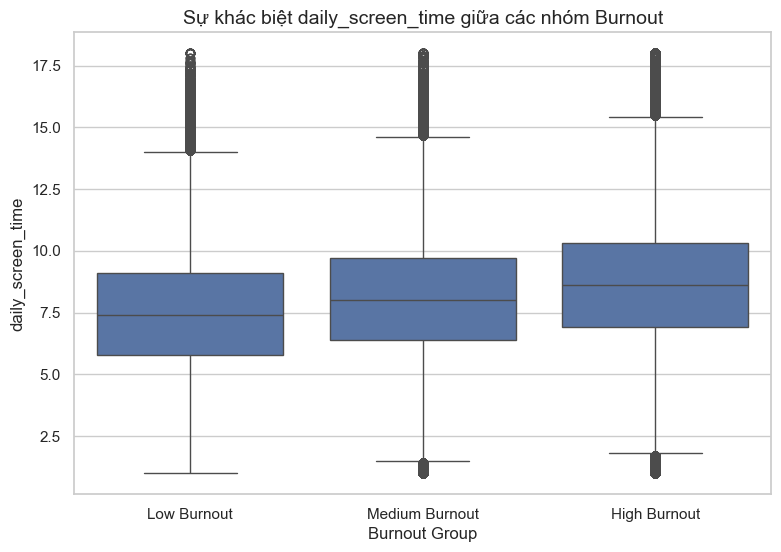

Nhận xét: Boxplot cho thấy sự khác biệt phân phối của daily_screen_time giữa các nhóm burnout.



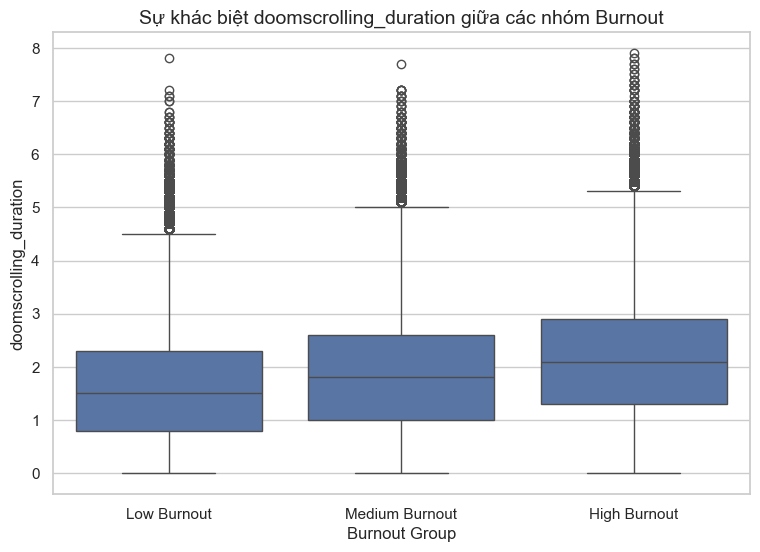

Nhận xét: Boxplot cho thấy sự khác biệt phân phối của doomscrolling_duration giữa các nhóm burnout.



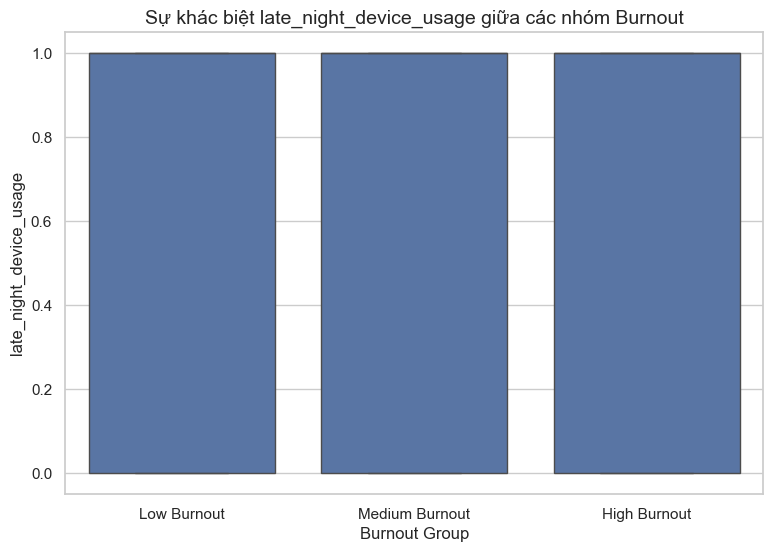

Nhận xét: Boxplot cho thấy sự khác biệt phân phối của late_night_device_usage giữa các nhóm burnout.



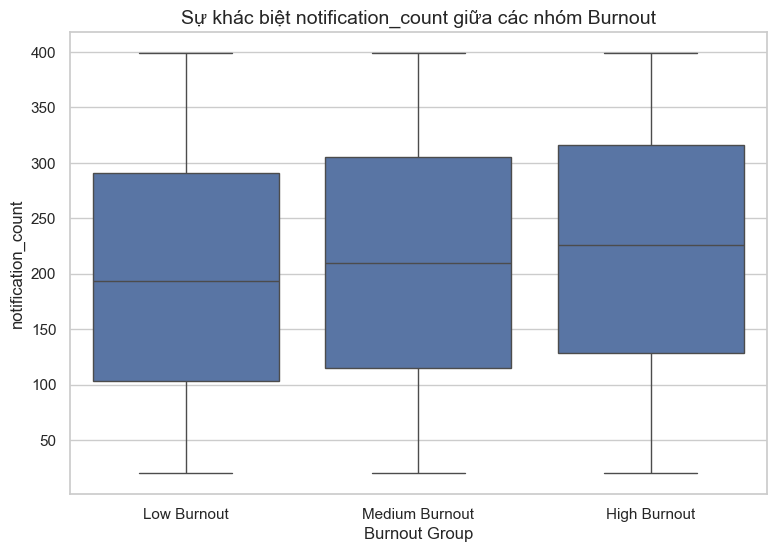

Nhận xét: Boxplot cho thấy sự khác biệt phân phối của notification_count giữa các nhóm burnout.



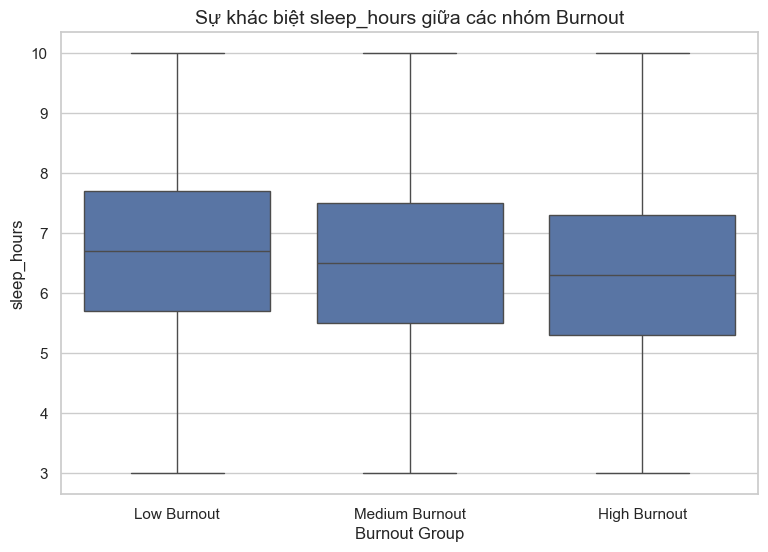

Nhận xét: Boxplot cho thấy sự khác biệt phân phối của sleep_hours giữa các nhóm burnout.



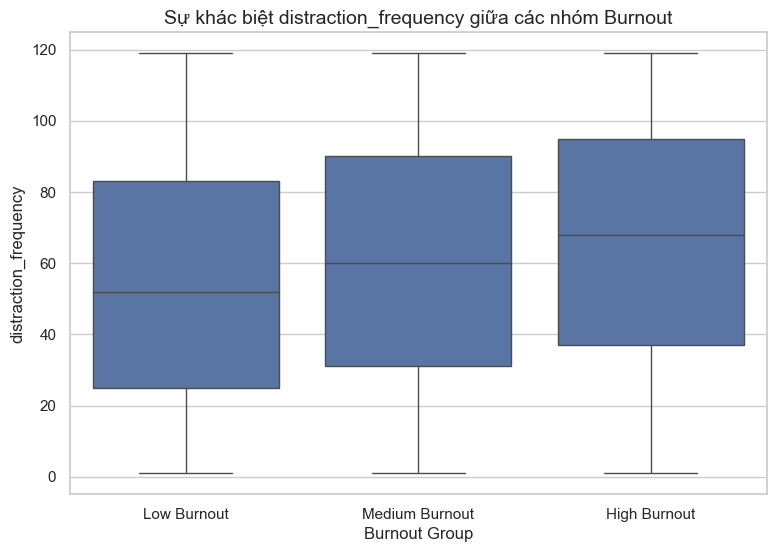

Nhận xét: Boxplot cho thấy sự khác biệt phân phối của distraction_frequency giữa các nhóm burnout.



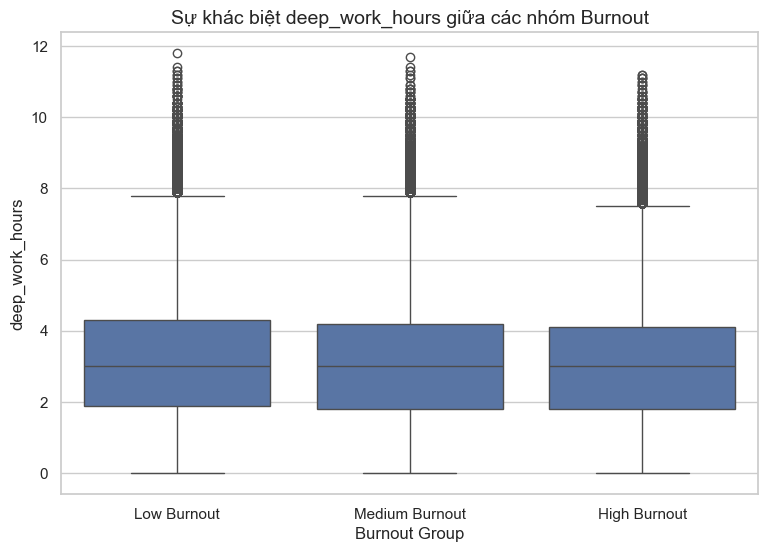

Nhận xét: Boxplot cho thấy sự khác biệt phân phối của deep_work_hours giữa các nhóm burnout.



In [83]:
# Boxplot for significant ANOVA variables

if not anova_results_df.empty:
    significant_anova_vars = anova_results_df[
        anova_results_df["significant_at_0.05"] == True
    ]["variable"].head(8).tolist()

    for col in significant_anova_vars:
        plt.figure(figsize=(9, 6))
        sns.boxplot(
            data=df_eda,
            x="burnout_group",
            y=col
        )
        plt.title(f"Sự khác biệt {col} giữa các nhóm Burnout")
        plt.xlabel("Burnout Group")
        plt.ylabel(col)
        plt.show()

        print(f"Nhận xét: Boxplot cho thấy sự khác biệt phân phối của {col} giữa các nhóm burnout.\n")

In [84]:
# Chi-square test for context variables and burnout group

chi_square_results = []

if "burnout_group" in df_eda.columns:
    for col in context_variables:
        if col in df_eda.columns:
            contingency_table = pd.crosstab(df_eda[col], df_eda["burnout_group"])

            chi2, p_value, dof, expected = chi2_contingency(contingency_table)

            chi_square_results.append({
                "context_variable": col,
                "chi2_statistic": chi2,
                "p_value": p_value,
                "degrees_of_freedom": dof,
                "significant_at_0.05": p_value < 0.05
            })

chi_square_results_df = pd.DataFrame(chi_square_results)

if not chi_square_results_df.empty:
    display(chi_square_results_df)
else:
    print("Không có biến context dạng gốc để thực hiện Chi-square test.")

,context_variable,chi2_statistic,p_value,degrees_of_freedom,significant_at_0.05
0,work_mode,0.852281,0.931305,4,False
1,device_usage_type,1.269555,0.866519,4,False


In [85]:
# Chi-square test for one-hot encoded context variables

encoded_chi_square_results = []

if "burnout_group" in df_eda.columns:
    encoded_context_cols = work_mode_encoded_cols + device_usage_encoded_cols

    for col in encoded_context_cols:
        contingency_table = pd.crosstab(df_eda[col], df_eda["burnout_group"])

        chi2, p_value, dof, expected = chi2_contingency(contingency_table)

        encoded_chi_square_results.append({
            "encoded_context_variable": col,
            "chi2_statistic": chi2,
            "p_value": p_value,
            "degrees_of_freedom": dof,
            "significant_at_0.05": p_value < 0.05
        })

encoded_chi_square_results_df = pd.DataFrame(encoded_chi_square_results)

if not encoded_chi_square_results_df.empty:
    encoded_chi_square_results_df = encoded_chi_square_results_df.sort_values(by="p_value")
    display(encoded_chi_square_results_df)
else:
    print("Không có biến context encoded để thực hiện Chi-square test.")

Không có biến context encoded để thực hiện Chi-square test.


## Group Difference Visualization

Phần này trực quan hóa sự khác biệt giữa các nhóm burnout đối với các nhóm biến chính.

Các biểu đồ này hỗ trợ diễn giải:
- Nhóm burnout cao có mức exposure số cao hơn hay không.
- Nhóm burnout cao có chất lượng giấc ngủ thấp hơn hay không.
- Nhóm burnout cao có hiệu suất nhận thức thấp hơn hay không.

burnout_group,Low Burnout,Medium Burnout,High Burnout
daily_screen_time,7.419613,8.015685,8.597876
social_media_hours,3.517708,3.517209,3.516953
doomscrolling_duration,1.597387,1.834912,2.083785
late_night_device_usage,0.569176,0.653789,0.731251
notification_count,198.179667,209.811114,220.909109
smartphone_unlocks,157.019200,157.141230,156.972712
app_switch_frequency,129.536565,129.510548,129.445545
sleep_hours,6.699791,6.495237,6.296596
sleep_quality,5.504442,5.500812,5.502465
concentration_score,5.502973,5.497404,5.503119


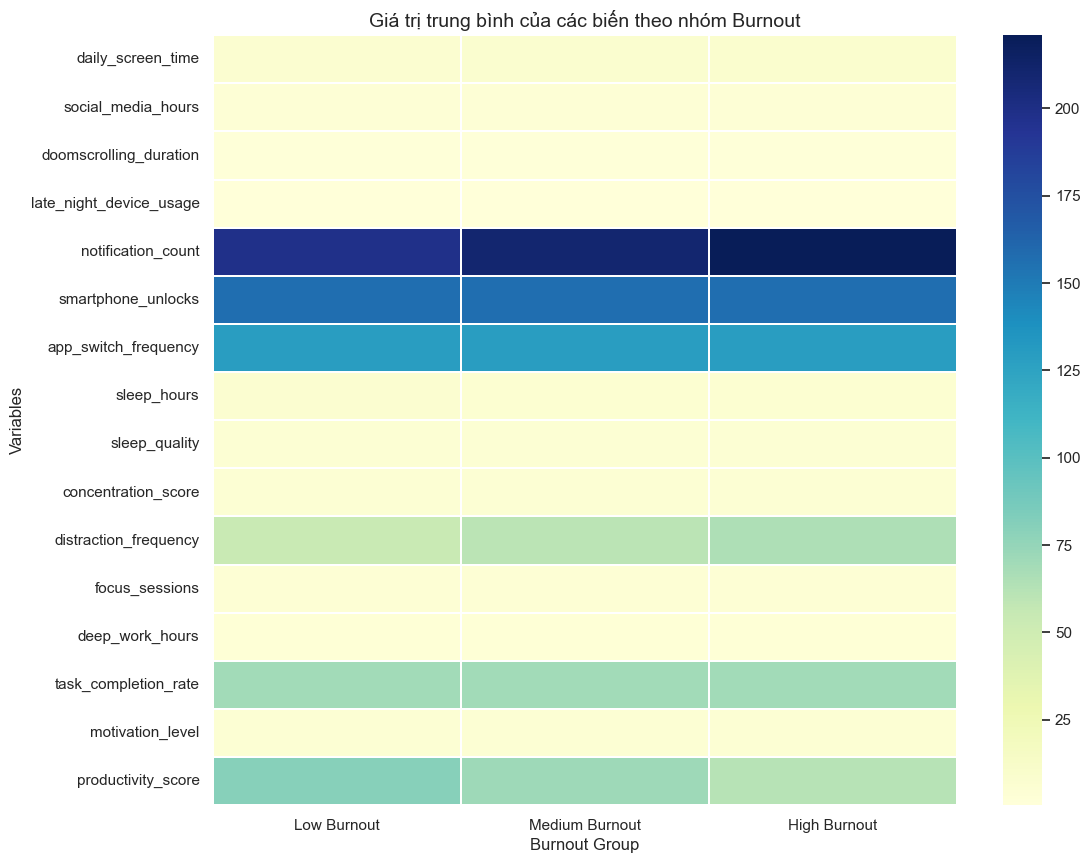

Nhận xét: Heatmap giúp so sánh xu hướng trung bình của các biến giữa nhóm burnout thấp, trung bình và cao.


In [86]:
# Mean comparison by burnout group

if "burnout_group" in df_eda.columns:
    group_mean_vars = [
        col for col in (
            digital_exposure
            + sleep_recovery
            + cognitive_performance
            + ["productivity_score"]
        )
        if col in df_eda.columns
    ]

    group_mean_table = df_eda.groupby("burnout_group")[group_mean_vars].mean().T

    display(group_mean_table)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        group_mean_table,
        cmap="YlGnBu",
        annot=False,
        linewidths=0.3
    )
    plt.title("Giá trị trung bình của các biến theo nhóm Burnout")
    plt.xlabel("Burnout Group")
    plt.ylabel("Variables")
    plt.show()

    print("Nhận xét: Heatmap giúp so sánh xu hướng trung bình của các biến giữa nhóm burnout thấp, trung bình và cao.")

## Key Insights

Phần này tổng hợp các phát hiện quan trọng từ EDA.

Các insight được tạo dựa trên:
- Tương quan với `burnout_risk`.
- Tương quan với `productivity_score`.
- Kết quả ANOVA.
- Kết quả Chi-square.
- So sánh trung bình giữa các nhóm burnout.

In [87]:
# Generate research-oriented insights

insights = []

# Insight from Pearson correlation with burnout_risk
if "burnout_risk" in pearson_corr.columns:
    burnout_corr_sorted = (
        pearson_corr["burnout_risk"]
        .drop("burnout_risk", errors="ignore")
        .sort_values(key=lambda x: x.abs(), ascending=False)
    )

    for variable, corr_value in burnout_corr_sorted.head(5).items():
        direction = "dương" if corr_value > 0 else "âm"
        insights.append(
            f"Biến {variable} có tương quan Pearson {direction} với burnout_risk "
            f"(r = {corr_value:.3f}), cho thấy đây có thể là yếu tố liên quan đáng chú ý đến Digital Burnout."
        )

# Insight from productivity_score
if "productivity_score" in pearson_corr.columns:
    productivity_corr_sorted = (
        pearson_corr["productivity_score"]
        .drop("productivity_score", errors="ignore")
        .sort_values(key=lambda x: x.abs(), ascending=False)
    )

    for variable, corr_value in productivity_corr_sorted.head(3).items():
        direction = "dương" if corr_value > 0 else "âm"
        insights.append(
            f"Biến {variable} có tương quan Pearson {direction} với productivity_score "
            f"(r = {corr_value:.3f}), phản ánh mối liên hệ với hiệu suất học tập/làm việc."
        )

# Insight from ANOVA
if not anova_results_df.empty:
    significant_vars = anova_results_df[
        anova_results_df["significant_at_0.05"] == True
    ]["variable"].head(5).tolist()

    for variable in significant_vars:
        insights.append(
            f"Kết quả ANOVA cho thấy {variable} có sự khác biệt có ý nghĩa thống kê giữa các nhóm burnout "
            f"(p < 0.05)."
        )

# Insight from Chi-square
if not chi_square_results_df.empty:
    sig_context = chi_square_results_df[
        chi_square_results_df["significant_at_0.05"] == True
    ]["context_variable"].tolist()

    for variable in sig_context:
        insights.append(
            f"Kiểm định Chi-square cho thấy {variable} có mối liên hệ có ý nghĩa thống kê với nhóm burnout "
            f"(p < 0.05)."
        )

if not encoded_chi_square_results_df.empty:
    sig_encoded_context = encoded_chi_square_results_df[
        encoded_chi_square_results_df["significant_at_0.05"] == True
    ]["encoded_context_variable"].head(3).tolist()

    for variable in sig_encoded_context:
        insights.append(
            f"Biến bối cảnh encoded {variable} có liên hệ có ý nghĩa thống kê với nhóm burnout "
            f"(p < 0.05)."
        )

# Ensure at least 10 displayed insights if available
print("KEY INSIGHTS")
print("-" * 80)

for idx, insight in enumerate(insights[:10], start=1):
    print(f"{idx}. {insight}")

if len(insights) < 10:
    print("\nLưu ý: Số insight tự động ít hơn 10 vì dữ liệu hoặc kết quả kiểm định không đủ biến có ý nghĩa rõ ràng.")

KEY INSIGHTS
--------------------------------------------------------------------------------
1. Biến emotional_exhaustion có tương quan Pearson dương với burnout_risk (r = 0.512), cho thấy đây có thể là yếu tố liên quan đáng chú ý đến Digital Burnout.
2. Biến stress_level có tương quan Pearson dương với burnout_risk (r = 0.383), cho thấy đây có thể là yếu tố liên quan đáng chú ý đến Digital Burnout.
3. Biến productivity_score có tương quan Pearson âm với burnout_risk (r = -0.378), cho thấy đây có thể là yếu tố liên quan đáng chú ý đến Digital Burnout.
4. Biến daily_screen_time có tương quan Pearson dương với burnout_risk (r = 0.221), cho thấy đây có thể là yếu tố liên quan đáng chú ý đến Digital Burnout.
5. Biến doomscrolling_duration có tương quan Pearson dương với burnout_risk (r = 0.200), cho thấy đây có thể là yếu tố liên quan đáng chú ý đến Digital Burnout.
6. Biến deep_work_hours có tương quan Pearson dương với productivity_score (r = 0.555), phản ánh mối liên hệ với hiệu suất h